## Célula 1

# Tech Challenge — Predição de Sepse

Este notebook reúne todo o pipeline do projeto em um único fluxo, desde o carregamento dos dados até a avaliação final do modelo.

A estrutura foi organizada para ficar mais adequada a uma apresentação acadêmica. Cada etapa é introduzida por uma célula de markdown com explicações objetivas sobre:

- o que será feito;
- por que essa etapa é importante;
- qual decisão metodológica foi adotada.

Além disso, o notebook foi separado em células menores, para que cada etapa tenha uma função bem definida e fique mais fácil de entender, revisar e apresentar.

In [1]:
# Célula 2
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Célula 3

# Configuração do experimento

Nesta etapa definimos os caminhos principais do projeto e as escolhas gerais do experimento.

A principal decisão aqui é controlar se variáveis administrativas e temporais, como `ICULOS` e `HospAdmTime`, serão usadas na modelagem. A recomendação inicial é começar sem essas variáveis para reduzir o risco de vazamento temporal e deixar o modelo mais coerente do ponto de vista clínico.

In [2]:
# Célula 4
from pathlib import Path

ROOT = Path.cwd().parent

DATA_PROCESSED = ROOT / "data" / "processed"

CAMINHO_TREINO = DATA_PROCESSED / "train_melhor.parquet"
CAMINHO_VAL = DATA_PROCESSED / "val_melhor.parquet"
CAMINHO_TESTE = DATA_PROCESSED / "test_melhor.parquet"

USAR_TEMPO_ADMIN = False
NOME_EXPERIMENTO = "com_tempo_admin" if USAR_TEMPO_ADMIN else "sem_tempo_admin"

PASTA_MODELOS = ROOT / "modelos_salvos"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

CAMINHO_MODELO = PASTA_MODELOS / f"modelo_sepse_{NOME_EXPERIMENTO}.pkl"
VERSAO_PIPELINE = f"v3.0_melhor_{NOME_EXPERIMENTO}"

print("ROOT:", ROOT)
print("Treino:", CAMINHO_TREINO)
print("Val:", CAMINHO_VAL)
print("Teste:", CAMINHO_TESTE)

ROOT: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0
Treino: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0\data\processed\train_melhor.parquet
Val: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0\data\processed\val_melhor.parquet
Teste: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0\data\processed\test_melhor.parquet


## Célula 5

# Contexto clínico e origem dos dados

Este projeto utiliza dados do **PhysioNet/Computing in Cardiology Challenge 2019**, uma base pública desenvolvida para a tarefa de **predição precoce de sepse** em pacientes críticos. O desafio foi estruturado para prever sepse com antecedência, utilizando registros clínicos horários compostos por sinais vitais, exames laboratoriais e variáveis demográficas.

A escolha dessa base foi adequada ao objetivo do trabalho porque ela representa um cenário realista de apoio à decisão clínica em terapia intensiva, no qual o modelo precisa lidar com dados temporais, valores ausentes, diferentes frequências de coleta e evolução fisiológica do paciente ao longo do tempo.

Além disso, a definição de sepse adotada no desafio foi baseada nos critérios do **Sepsis-3**, segundo os quais a sepse é entendida como uma **disfunção orgânica ameaçadora à vida causada por uma resposta desregulada do organismo à infecção**. Essa definição foi importante para orientar a escolha das variáveis mais relevantes e para evitar que o problema fosse tratado apenas como uma classificação genérica de pacientes graves.

Dessa forma, o projeto foi construído a partir de uma base pública reconhecida na literatura, com uma definição clínica contemporânea de sepse e com foco específico em **detecção antecipada**, o que torna a abordagem metodologicamente coerente com a finalidade do estudo.

## Célula 6

# Leitura dos conjuntos de treino, validação e teste

Aqui carregamos os três conjuntos já preparados para o projeto.

Essa separação é importante porque:

- o treino será usado para ajustar os modelos;
- a validação será usada para escolher o melhor algoritmo e o melhor threshold;
- o teste será reservado para a avaliação final.

Essa divisão evita que decisões metodológicas sejam tomadas diretamente sobre o conjunto de teste.

In [3]:
# Célula 7
df_train = pd.read_parquet(CAMINHO_TREINO)
df_val = pd.read_parquet(CAMINHO_VAL)
df_test = pd.read_parquet(CAMINHO_TESTE)

## Célula 8

# Verificação inicial da estrutura dos dados

Antes de iniciar o pré-processamento, é importante conferir se os dados foram carregados corretamente.

Nesta etapa, observamos:

- o tamanho de cada conjunto;
- a presença da variável alvo `SepsisLabel`;
- uma amostra inicial das colunas.

Essa validação inicial ajuda a identificar problemas simples logo no começo do fluxo.

In [4]:
# Célula 9
print("Treino:", df_train.shape)
print("Validação:", df_val.shape)
print("Teste:", df_test.shape)
print()

print("SepsisLabel no treino:", "SepsisLabel" in df_train.columns)
print("SepsisLabel na validação:", "SepsisLabel" in df_val.columns)
print("SepsisLabel no teste:", "SepsisLabel" in df_test.columns)
print()

display(df_train.head())

Treino: (631120, 226)
Validação: (159095, 226)
Teste: (761995, 226)

SepsisLabel no treino: True
SepsisLabel na validação: True
SepsisLabel no teste: True



,patient_id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,dataset_origem,HR_missing,O2Sat_missing,Temp_missing,SBP_missing,MAP_missing,DBP_missing,Resp_missing,Lactate_missing,WBC_missing,Creatinine_missing,Platelets_missing,Bilirubin_total_missing,BUN_missing,pH_missing,PaCO2_missing,SaO2_missing,PTT_missing,Fibrinogen_missing,flag_taquicardia_90,flag_taquicardia_100,flag_temp_anormal,flag_febre,flag_hipotermia,flag_taquipneia_20,flag_taquipneia_22,flag_map_baixa,flag_sbp_baixa_90,flag_sbp_baixa_100,flag_o2_baixo_92,flag_o2_baixo_90,flag_lactato_alto_2,flag_lactato_muito_alto_4,flag_wbc_alto,flag_wbc_baixo,flag_wbc_anormal,flag_creatinina_alta,flag_bun_alto,flag_plaqueta_baixa,flag_bilirrubina_alta,flag_ph_baixo,qtd_sinais_alterados,sirs_score,qsofa_like_score,organ_dysfunction_score,clinical_risk_score,flag_hr_normal,flag_temp_normal,flag_resp_normal,flag_map_normal,flag_o2_normal,flag_lactato_normal,stable_no_sepsis_score,Shock_Index,MAP_HR_ratio,Lactate_MAP_ratio,Resp_O2_ratio,BUN_Creatinine_ratio,...,MAP_mean_3h,MAP_mean_6h,MAP_mean_12h,MAP_worst_6h,MAP_worst_12h,DBP_diff_1h,DBP_mean_3h,DBP_mean_6h,DBP_mean_12h,DBP_worst_6h,DBP_worst_12h,Resp_diff_1h,Resp_mean_3h,Resp_mean_6h,Resp_mean_12h,Resp_worst_6h,Resp_worst_12h,Lactate_diff_1h,Lactate_mean_3h,Lactate_mean_6h,Lactate_mean_12h,Lactate_worst_6h,Lactate_worst_12h,WBC_diff_1h,WBC_mean_3h,WBC_mean_6h,WBC_mean_12h,WBC_worst_6h,WBC_worst_12h,Creatinine_diff_1h,Creatinine_mean_3h,Creatinine_mean_6h,Creatinine_mean_12h,Creatinine_worst_6h,Creatinine_worst_12h,Platelets_diff_1h,Platelets_mean_3h,Platelets_mean_6h,Platelets_mean_12h,Platelets_worst_6h,Platelets_worst_12h,Bilirubin_total_diff_1h,Bilirubin_total_mean_3h,Bilirubin_total_mean_6h,Bilirubin_total_mean_12h,Bilirubin_total_worst_6h,Bilirubin_total_worst_12h,BUN_diff_1h,BUN_mean_3h,BUN_mean_6h,BUN_mean_12h,BUN_worst_6h,BUN_worst_12h,pH_diff_1h,pH_mean_3h,pH_mean_6h,pH_mean_12h,pH_worst_6h,pH_worst_12h,flag_map_baixa_count_3h,flag_map_baixa_count_6h,flag_map_baixa_count_12h,flag_lactato_alto_2_count_3h,flag_lactato_alto_2_count_6h,flag_lactato_alto_2_count_12h,flag_lactato_muito_alto_4_count_3h,flag_lactato_muito_alto_4_count_6h,flag_lactato_muito_alto_4_count_12h,flag_taquicardia_100_count_3h,flag_taquicardia_100_count_6h,flag_taquicardia_100_count_12h,flag_taquipneia_22_count_3h,flag_taquipneia_22_count_6h,flag_taquipneia_22_count_12h,flag_temp_anormal_count_3h,flag_temp_anormal_count_6h,flag_temp_anormal_count_12h,flag_wbc_anormal_count_3h,flag_wbc_anormal_count_6h,flag_wbc_anormal_count_12h,flag_creatinina_alta_count_3h,flag_creatinina_alta_count_6h,flag_creatinina_alta_count_12h,flag_plaqueta_baixa_count_3h,flag_plaqueta_baixa_count_6h,flag_plaqueta_baixa_count_12h,flag_o2_baixo_92_count_3h,flag_o2_baixo_92_count_6h,flag_o2_baixo_92_count_12h,HR_std_6h,HR_std_12h,MAP_std_6h,MAP_std_12h,Resp_std_6h,Resp_std_12h,O2Sat_std_6h,O2Sat_std_12h,Temp_std_6h,Temp_std_12h,paciente_teve_sepse
0,p000001,84.0,98.0,36.939999,118.5,77.000000,59.0,18.0,0.0,0.0,24.0,0.50,7.39,40.0,97.0,55.0,18.0,79.0,8.3,106.0,0.9,1.2,124.0,1.6,2.0,3.4,4.1,0.9,4.3,30.5,10.5,31.9,10.9,256.0,185.0,83.139999,0,1.0,0.0,-0.03,1,0,A,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.703125,0.923913,0.021591,0.185567,18.333332,...,77.333336,77.333336,77.416664,69.000000,66.330002,0.0,59.0,59.0,59.25,65.5,68.0,0.0,18.000000,18.083334,18.000000,21.5,23.0,0.0,1.6,1.6,1.6,1.7,1.7,0.0,10.9,10.9,10.9,11.0,11.1,0.0,0.9,0.9,0.9,0.9,0.9,0.0,186.0,188.0,191.0,187.0,188.0,0.0,0.8,0.8,0.8,0.8,0.8,0.0,17.0,17.0,17.0,17.0,18.0,0.0,7.39,7.39,7.39,7.38,7.37,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.308906,5.354126,6.121002,7.149380,2.408319,2.74137

## Célula 10

# Distribuição da variável alvo

Como este é um problema fortemente desbalanceado, precisamos verificar quantos registros pertencem à classe sem sepse e quantos pertencem à classe com sepse.

Essa análise é fundamental porque, em cenários médicos, uma acurácia alta pode ser enganosa quando a classe positiva é rara. Por isso, desde o início, o foco deve estar em métricas como recall, precisão, F1 e principalmente falsos negativos.

## Célula 11

# Justificativa da estrutura do problema

A análise inicial da variável alvo mostrou que o problema é **fortemente desbalanceado**, com muito mais registros sem sepse do que registros com sepse. Esse comportamento é esperado em bases clínicas reais, nas quais os eventos de maior gravidade costumam ser menos frequentes do que os casos negativos.

Por esse motivo, o desempenho do modelo não pode ser interpretado apenas por acurácia. Em um problema como este, um modelo pode apresentar acurácia elevada e, ainda assim, falhar justamente nos casos mais importantes. Por isso, métricas como **recall, falsos negativos, precisão, F1-score e taxa de alerta** passaram a ter papel central na avaliação.

No contexto clínico, os **falsos negativos** merecem atenção especial, pois representam pacientes com sepse que não foram corretamente identificados pelo modelo. Como a sepse é uma condição associada à rápida deterioração clínica e maior risco de mortalidade, deixar de sinalizar um caso verdadeiro pode reduzir a utilidade prática do sistema.

Assim, o projeto foi tratado como uma ferramenta de **triagem clínica assistida por dados**, em que a prioridade não é substituir o julgamento médico, mas gerar alertas precoces que auxiliem a investigação e a tomada de decisão.

## Célula 12

# Fundamentação clínica das decisões de pré-processamento

O pré-processamento foi estruturado para preservar o significado clínico dos dados e, ao mesmo tempo, reduzir ruídos que poderiam prejudicar a modelagem.

A primeira decisão importante foi a utilização de **limites fisiológicos plausíveis** para identificar valores extremamente improváveis. Esses valores não foram tratados como critério diagnóstico, mas como possíveis erros de medição, registro ou integração de dados. Ao transformá-los em valores ausentes, evitamos que o modelo aprendesse padrões irreais.

Outra decisão relevante foi a criação de **indicadores de ausência de dados**. Em ambientes hospitalares, o fato de um exame ter sido solicitado ou não também pode carregar informação clínica. Em muitos casos, a ausência de uma medição não é apenas falta de dado, mas também reflexo de uma decisão assistencial. Por isso, variáveis de missing foram mantidas como parte do pipeline.

Também foi aplicado **forward fill limitado por paciente**, de forma controlada. Essa escolha foi adotada porque, em séries temporais clínicas, o último valor conhecido de um sinal vital ou exame pode ainda representar o estado recente do paciente. No entanto, o preenchimento foi limitado a uma janela curta para evitar que medições antigas fossem propagadas de forma excessiva.

Essas decisões foram tomadas para que o modelo utilizasse dados mais consistentes, respeitando o caráter temporal da base e mantendo o foco em uma interpretação clinicamente plausível.

In [5]:
# Célula 13
for nome, df in {"Treino": df_train, "Validação": df_val, "Teste": df_test}.items():
    print(f"===== {nome} =====")
    print(df["SepsisLabel"].value_counts(dropna=False))
    print()
    print(df["SepsisLabel"].value_counts(normalize=True, dropna=False))
    print("-" * 60)

===== Treino =====
SepsisLabel
0    617410
1     13710
Name: count, dtype: int64

SepsisLabel
0    0.978277
1    0.021723
Name: proportion, dtype: float64
------------------------------------------------------------
===== Validação =====
SepsisLabel
0    155669
1      3426
Name: count, dtype: int64

SepsisLabel
0    0.978466
1    0.021534
Name: proportion, dtype: float64
------------------------------------------------------------
===== Teste =====
SepsisLabel
0    751215
1     10780
Name: count, dtype: int64

SepsisLabel
0    0.985853
1    0.014147
Name: proportion, dtype: float64
------------------------------------------------------------


## Célula 14

# Gráfico da distribuição da variável alvo

Além da tabela com contagens e proporções, este gráfico mostra visualmente o desbalanceamento entre registros com sepse e sem sepse nos conjuntos de treino, validação e teste.

A escala logarítmica foi usada para permitir visualizar melhor a classe positiva, que costuma ser muito menor.

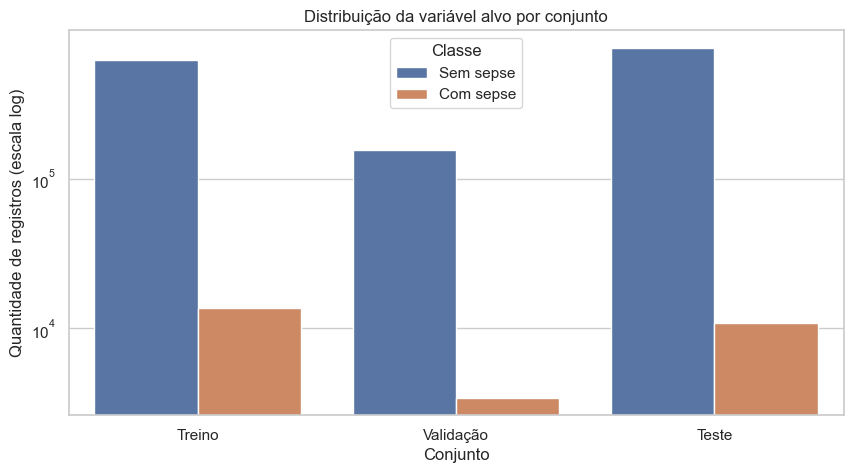

In [6]:
# Célula 15
.2
def plotar_distribuicao_alvo(datasets):
    base = pd.concat(
        [
            df["SepsisLabel"]
            .value_counts()
            .rename_axis("classe")
            .reset_index(name="quantidade")
            .assign(conjunto=nome)
            for nome, df in datasets.items()
        ],
        ignore_index=True
    )

    base["classe"] = base["classe"].map({0: "Sem sepse", 1: "Com sepse"})

    plt.figure(figsize=(10, 5))
    sns.barplot(data=base, x="conjunto", y="quantidade", hue="classe")
    plt.yscale("log")
    plt.title("Distribuição da variável alvo por conjunto")
    plt.xlabel("Conjunto")
    plt.ylabel("Quantidade de registros (escala log)")
    plt.legend(title="Classe")
    plt.show()


plotar_distribuicao_alvo(
    {"Treino": df_train, "Validação": df_val, "Teste": df_test}
)

## Célula 16

### Interpretação do gráfico: distribuição da variável alvo por conjunto

Este gráfico mostra a quantidade de registros **com sepse** e **sem sepse** nos conjuntos de **treino**, **validação** e **teste**. O eixo Y está em **escala logarítmica**, o que foi necessário porque existe uma diferença muito grande entre as classes.

O principal ponto que o gráfico evidencia é que o problema é **fortemente desbalanceado**: em todos os conjuntos, a quantidade de registros **sem sepse** é muito maior do que a quantidade de registros **com sepse**. Isso significa que o modelo aprende em um cenário em que a classe positiva é rara, o que torna a detecção de sepse mais difícil.

Também entendemos que:
- o **conjunto de treino** possui maior volume de dados, o que é esperado;
- o **conjunto de validação** é menor, mas mantém o mesmo padrão de desbalanceamento;
- o **conjunto de teste** apresenta uma distribuição parecida com a de treino, o que é importante para avaliar o modelo em um cenário coerente com os dados reais.

Esse gráfico é importante porque ajuda a justificar por que métricas como **accuracy** sozinhas não são suficientes neste problema. Em bases muito desbalanceadas, um modelo pode parecer bom apenas por acertar a classe majoritária. Por isso, neste contexto, faz mais sentido analisar métricas como **recall**, **precision**, **falsos negativos (FN)** e **falsos positivos (FP)**.

Em resumo, o gráfico mostra que:
**o modelo está sendo treinado e avaliado em uma base altamente desbalanceada, com muito mais casos sem sepse do que com sepse, o que exige cuidado na interpretação das métricas e no ajuste do modelo.**

## Célula 17

# Interpretação da distribuição da variável alvo

Nesta etapa, espera-se observar um volume muito maior de registros sem sepse do que com sepse. Isso confirma que o problema é desbalanceado e justifica a necessidade de uma estratégia de modelagem cuidadosa.

A partir dessa distribuição, entendemos que o modelo não pode ser avaliado apenas por acurácia. O mais importante é reduzir ao máximo os falsos negativos, já que deixar de identificar um caso de sepse pode ter impacto clínico grave.

In [7]:
# Célula 18
COLUNAS_CLINICAS_BASE = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Lactate", "WBC", "Creatinine", "Platelets", "pH", "HCO3"
]

SINAIS_VITAIS_FFILL = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]

PESOS_FLAGS_CLINICAS = {
    "flag_taquicardia": 1.0,
    "flag_hipoxemia": 2.0,
    "flag_febre": 1.0,
    "flag_hipotermia": 1.5,
    "flag_hipotensao_sistolica": 2.0,
    "flag_hipotensao_map": 3.0,
    "flag_taquipneia": 1.5,
    "flag_lactato_alto": 3.0,
    "flag_lactato_muito_alto_4": 4.0,
    "flag_leucocitos_alterados": 1.0,
    "flag_plaquetopenia": 2.0,
    "flag_disfuncao_renal": 2.5,
    "flag_very_high_creatinine": 3.5,
    "flag_acidose": 3.0,
    "flag_bicarbonato_baixo": 2.0,
    "flag_shock_index_alto": 2.5,
    "flag_hipoperfusao_importante": 4.0,
    "flag_desconforto_respiratorio": 2.5,
    "flag_disfuncao_metabolica_renal": 3.5,
    "flag_resposta_inflamatoria": 2.0,
}

LIMITES_FISIOLOGICOS = {
    "HR": (20, 250),
    "O2Sat": (40, 100),
    "Temp": (30, 43),
    "SBP": (40, 300),
    "MAP": (30, 200),
    "DBP": (20, 180),
    "Resp": (4, 80),
    "Lactate": (0, 20),
    "WBC": (0.1, 100),
    "Creatinine": (0.1, 20),
    "Platelets": (1, 1500),
    "pH": (6.8, 7.8),
    "HCO3": (1, 60),
}

## Célula 19

# Proporção de valores ausentes nas variáveis clínicas

Antes de aplicar o tratamento de missing, é importante visualizar quais variáveis clínicas possuem maior proporção de valores ausentes no conjunto de treino.

Isso ajuda a justificar tecnicamente as decisões de imputação e preenchimento temporal.

In [ ]:
# Célula 20 
colunas_validas = [c for c in COLUNAS_CLINICAS_BASE if c in df_train.columns]

base = (
    df_train[colunas_validas]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
base.columns = ["variavel", "proporcao_missing"]

display(base)

print("Total de variáveis clínicas com missing > 0:", (base["proporcao_missing"] > 0).sum())

,variavel,proporcao_missing
0,HR,0.0
1,O2Sat,0.0
2,Temp,0.0
3,SBP,0.0
4,MAP,0.0
5,DBP,0.0
6,Resp,0.0
7,Lactate,0.0
8,WBC,0.0
9,Creatinine,0.0


Total de variáveis clínicas com missing > 0: 0


## Célula 21

### Interpretação da análise de valores ausentes nas variáveis clínicas

A verificação de valores ausentes no conjunto de treino não gerou barras no gráfico porque, após o tratamento dos dados, nenhuma das variáveis clínicas avaliadas apresentou proporção de missing maior que zero.

Isso indica que o processo de tratamento de ausências foi aplicado com sucesso ao conjunto de treino utilizado na modelagem. Portanto, nesta etapa, não há mais valores ausentes relevantes nessas variáveis clínicas.

Em outras palavras, a ausência de gráfico não representa erro na visualização, mas sim que o conjunto já estava completamente tratado no momento da análise.

## Célula 22

# Função de ordenação temporal por paciente

Como o projeto utiliza informações temporais, é essencial garantir que os registros estejam ordenados por paciente e pelo tempo dentro da UTI.

Essa organização é importante porque várias features dependem da sequência cronológica dos eventos, como médias móveis, diferenças e contadores de persistência.

In [9]:
# Célula 23
def ordenar_por_paciente_tempo(df):
    if "patient_id" in df.columns and "ICULOS" in df.columns:
        return df.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)
    return df.reset_index(drop=True)

## Célula 24

# Função de limpeza de valores fisiologicamente improváveis

Nesta etapa, transformamos em valores ausentes as medições que estejam fora de limites fisiológicos plausíveis.

O objetivo não é aplicar um critério diagnóstico, mas reduzir ruídos gerados por erros de medição, digitação ou registro.

In [10]:
# Célula 25
def limpar_valores_fisiologicos(df):
    df = df.copy()

    for col, (min_v, max_v) in LIMITES_FISIOLOGICOS.items():
        if col in df.columns:
            mascara_invalida = (df[col] < min_v) | (df[col] > max_v)
            df.loc[mascara_invalida, col] = np.nan

    return df

## Célula 26

# Função de soma móvel por paciente

Essa função calcula quantas vezes determinado evento ocorreu dentro de uma janela recente para o mesmo paciente.

Ela será usada para representar persistência clínica, o que é importante porque alterações repetidas ao longo do tempo podem indicar maior gravidade do que alterações isoladas.

In [11]:
# Célula 27
def rolling_sum_por_paciente(df, coluna, janela):
    if "patient_id" not in df.columns or coluna not in df.columns:
        return pd.Series(0.0, index=df.index)

    return (
        df.groupby("patient_id")[coluna]
        .transform(lambda x: x.rolling(janela, min_periods=1).sum())
        .astype(float)
    )

## Célula 28

# Função de estatística móvel por paciente

Essa função calcula estatísticas recentes de uma variável para cada paciente, como média, máximo, mínimo e desvio padrão.

Essas medidas permitem representar o comportamento temporal dos sinais clínicos, o que enriquece a capacidade do modelo de reconhecer piora ou instabilidade.

In [12]:
# Célula 29
def rolling_stat_por_paciente(df, coluna, janela, operacao):
    if "patient_id" not in df.columns or coluna not in df.columns:
        return pd.Series(0.0, index=df.index)

    serie = df.groupby("patient_id")[coluna]

    if operacao == "mean":
        return serie.transform(lambda x: x.rolling(janela, min_periods=1).mean())
    if operacao == "max":
        return serie.transform(lambda x: x.rolling(janela, min_periods=1).max())
    if operacao == "min":
        return serie.transform(lambda x: x.rolling(janela, min_periods=1).min())
    if operacao == "std":
        return serie.transform(lambda x: x.rolling(janela, min_periods=1).std()).fillna(0)

    raise ValueError(f"Operação inválida: {operacao}")

## Célula 30

# Função de diferença temporal por paciente

A diferença temporal mostra a variação entre a medição atual e a medição anterior do mesmo paciente.

Esse tipo de feature é útil porque a sepse pode se manifestar não apenas por valores absolutos alterados, mas também por pioras rápidas em pouco tempo.

In [13]:
# Célula 31
def diff_por_paciente(df, coluna):
    if "patient_id" not in df.columns or coluna not in df.columns:
        return pd.Series(0.0, index=df.index)

    return (
        df.groupby("patient_id")[coluna]
        .diff()
        .fillna(0)
        .astype(float)
    )

## Célula 32

# Contadores de persistência clínica

Nesta etapa criamos variáveis que indicam quantas vezes determinados sinais alterados apareceram recentemente.

A persistência de alterações como hipotensão, hipoxemia, taquipneia e lactato elevado pode ser mais relevante do que uma única alteração isolada. Por isso, esses contadores ajudam o modelo a refletir melhor a evolução clínica do paciente.

In [14]:
# Célula 33
def adicionar_contadores_de_persistencia(df):
    mapeamento = {
        "flag_hipotensao_map": "low_map",
        "flag_lactato_alto": "high_lactate",
        "flag_taquipneia": "high_resp",
        "flag_hipoxemia": "low_o2",
        "flag_febre": "fever",
        "flag_hipotermia": "hypothermia",
        "flag_disfuncao_renal": "renal_dysfunction",
        "flag_acidose": "acidosis",
    }

    for col_flag, prefixo in mapeamento.items():
        if col_flag in df.columns:
            df[f"{prefixo}_count_3h"] = rolling_sum_por_paciente(df, col_flag, 3)
            df[f"{prefixo}_count_6h"] = rolling_sum_por_paciente(df, col_flag, 6)

    return df

## Célula 34

# Interações clínicas entre variáveis

Nem sempre uma variável isolada representa bem a gravidade do paciente. Em muitos casos, o que indica risco é a combinação de sinais.

Por isso, nesta etapa criamos interações clínicas relevantes, como:

- índice de choque;
- pressão de pulso;
- hipoperfusão importante;
- desconforto respiratório;
- disfunção metabólica com componente renal;
- resposta inflamatória.

Essas combinações tornam o modelo mais próximo do raciocínio clínico.

## Célula 35

# Fundamentação clínica das decisões de pré-processamento

O pré-processamento foi estruturado para preservar o significado clínico dos dados e, ao mesmo tempo, reduzir ruídos que poderiam prejudicar a modelagem.

A primeira decisão importante foi a utilização de **limites fisiológicos plausíveis** para identificar valores extremamente improváveis. Esses valores não foram tratados como critério diagnóstico, mas como possíveis erros de medição, registro ou integração de dados. Ao transformá-los em valores ausentes, evitamos que o modelo aprendesse padrões irreais.

Outra decisão relevante foi a criação de **indicadores de ausência de dados**. Em ambientes hospitalares, o fato de um exame ter sido solicitado ou não também pode carregar informação clínica. Em muitos casos, a ausência de uma medição não é apenas falta de dado, mas também reflexo de uma decisão assistencial. Por isso, variáveis de missing foram mantidas como parte do pipeline.

Também foi aplicado **forward fill limitado por paciente**, de forma controlada. Essa escolha foi adotada porque, em séries temporais clínicas, o último valor conhecido de um sinal vital ou exame pode ainda representar o estado recente do paciente. No entanto, o preenchimento foi limitado a uma janela curta para evitar que medições antigas fossem propagadas de forma excessiva.

Essas decisões foram tomadas para que o modelo utilizasse dados mais consistentes, respeitando o caráter temporal da base e mantendo o foco em uma interpretação clinicamente plausível.

In [15]:
# Célula 36
def criar_interacoes_clinicas(df):
    df = df.copy()

    if "HR" in df.columns and "SBP" in df.columns:
        sbp_segura = df["SBP"].replace(0, np.nan)
        df["shock_index"] = (df["HR"] / sbp_segura).replace([np.inf, -np.inf], np.nan).fillna(0)
        df["flag_shock_index_alto"] = (df["shock_index"] >= 0.9).astype(int)

    if "SBP" in df.columns and "DBP" in df.columns:
        df["pulse_pressure"] = (df["SBP"] - df["DBP"]).astype(float)

    if "flag_lactato_alto" in df.columns and "flag_hipotensao_map" in df.columns:
        df["flag_hipoperfusao_importante"] = (
            (df["flag_lactato_alto"] == 1) & (df["flag_hipotensao_map"] == 1)
        ).astype(int)

    if "flag_hipoxemia" in df.columns and "flag_taquipneia" in df.columns:
        df["flag_desconforto_respiratorio"] = (
            (df["flag_hipoxemia"] == 1) & (df["flag_taquipneia"] == 1)
        ).astype(int)

    if "flag_acidose" in df.columns and "flag_disfuncao_renal" in df.columns:
        df["flag_disfuncao_metabolica_renal"] = (
            (df["flag_acidose"] == 1) & (df["flag_disfuncao_renal"] == 1)
        ).astype(int)

    if "flag_leucocitos_alterados" in df.columns:
        temp_alterada = pd.Series(0, index=df.index)
        if "flag_febre" in df.columns:
            temp_alterada = temp_alterada | (df["flag_febre"] == 1)
        if "flag_hipotermia" in df.columns:
            temp_alterada = temp_alterada | (df["flag_hipotermia"] == 1)

        df["flag_resposta_inflamatoria"] = (
            temp_alterada.astype(int) & (df["flag_leucocitos_alterados"] == 1)
        ).astype(int)

    return df

## Célula 37

# Score ponderado de instabilidade clínica

Esta função resume vários sinais clínicos em uma única medida ponderada.

A ideia é representar de forma mais compacta a carga de instabilidade fisiológica do paciente. Os pesos atribuídos não correspondem a um escore médico oficial, mas ajudam o modelo a diferenciar melhor casos potencialmente mais graves.

In [16]:
# Célula 38
def montar_score_instabilidade_ponderado(df):
    score = pd.Series(0.0, index=df.index)

    for col, peso in PESOS_FLAGS_CLINICAS.items():
        if col in df.columns:
            score += df[col].fillna(0).astype(float) * peso

    return score

## Célula 39

# Quantidade de sinais clínicos alterados

Além do score ponderado, também calculamos a quantidade simples de sinais clínicos alterados.

Essa medida ajuda a representar quantos marcadores básicos de instabilidade estão presentes em cada linha, sem considerar pesos diferentes entre eles.

In [17]:
# Célula 40
def montar_qtd_sinais_basicos(df):
    flags_basicas = [
        "flag_taquicardia",
        "flag_hipoxemia",
        "flag_febre",
        "flag_hipotermia",
        "flag_hipotensao_sistolica",
        "flag_hipotensao_map",
        "flag_taquipneia",
        "flag_lactato_alto",
        "flag_leucocitos_alterados",
        "flag_plaquetopenia",
        "flag_disfuncao_renal",
        "flag_acidose",
        "flag_bicarbonato_baixo",
    ]

    existentes = [c for c in flags_basicas if c in df.columns]
    if not existentes:
        return pd.Series(0.0, index=df.index)

    return df[existentes].fillna(0).sum(axis=1).astype(float)

## Célula 41

# Score de disfunção orgânica

Nesta etapa criamos um score voltado para alterações mais relacionadas à disfunção orgânica, como hipotensão, lactato elevado, acidose, plaquetopenia e disfunção renal.

Esse score busca representar melhor casos clinicamente mais compatíveis com agravamento sistêmico.

In [18]:
# Célula 42
def montar_score_disfuncao_organica(df):
    flags_organicas = [
        "flag_lactato_alto",
        "flag_lactato_muito_alto_4",
        "flag_hipotensao_map",
        "flag_disfuncao_renal",
        "flag_very_high_creatinine",
        "flag_plaquetopenia",
        "flag_acidose",
        "flag_bicarbonato_baixo",
        "flag_hipoxemia",
        "flag_hipoperfusao_importante",
        "flag_disfuncao_metabolica_renal",
    ]

    pesos = {
        "flag_lactato_alto": 1.0,
        "flag_lactato_muito_alto_4": 2.0,
        "flag_hipotensao_map": 2.0,
        "flag_disfuncao_renal": 1.5,
        "flag_very_high_creatinine": 2.0,
        "flag_plaquetopenia": 1.5,
        "flag_acidose": 2.0,
        "flag_bicarbonato_baixo": 1.0,
        "flag_hipoxemia": 1.5,
        "flag_hipoperfusao_importante": 2.5,
        "flag_disfuncao_metabolica_renal": 2.5,
    }

    score = pd.Series(0.0, index=df.index)
    for col in flags_organicas:
        if col in df.columns:
            score += df[col].fillna(0).astype(float) * pesos[col]

    return score

## Célula 43

# Critério de seleção e priorização das variáveis

A seleção das variáveis foi guiada pela literatura clínica sobre sepse e pela lógica fisiopatológica do problema. Em vez de tratar todas as colunas como igualmente importantes, foram priorizadas as variáveis com maior capacidade de representar **perfusão, oxigenação, resposta inflamatória e disfunção orgânica**.

Por isso, receberam maior atenção variáveis como **frequência cardíaca (HR), temperatura (Temp), frequência respiratória (Resp), pressão arterial sistólica (SBP), pressão arterial média (MAP), saturação de oxigênio (O2Sat), lactato (Lactate), leucócitos (WBC), creatinina (Creatinine), plaquetas (Platelets), pH, bicarbonato (HCO3), ureia nitrogenada (BUN) e bilirrubina total (Bilirubin_total)**.

Essas variáveis foram priorizadas porque se relacionam diretamente com os principais eixos clínicos da sepse: instabilidade hemodinâmica, hipoperfusão, resposta inflamatória sistêmica, disfunção renal, alteração respiratória, disfunção hematológica e distúrbios metabólicos.

Algumas colunas foram tratadas como secundárias ou experimentais. Esse foi o caso de variáveis administrativas ou muito dependentes do contexto operacional, como `ICULOS` e `HospAdmTime`. Embora possam conter informação útil, elas também podem induzir o modelo a aprender atalhos relacionados ao tempo de internação, em vez de padrões fisiológicos diretamente associados à sepse. Por esse motivo, a estratégia inicial priorizou uma versão mais conservadora, sem essas variáveis.

Essa escolha buscou aumentar a coerência clínica do modelo e reduzir o risco de que o desempenho fosse artificialmente inflado por informação temporal administrativa.

## Célula 44

# Tratamento de valores ausentes

O tratamento de missing foi organizado com foco clínico e temporal.

A estratégia adotada é:

1. ordenar por paciente e tempo;
2. remover valores fisiologicamente absurdos;
3. criar flags de missing para colunas clínicas relevantes;
4. aplicar preenchimento temporal limitado nos sinais vitais;
5. preencher os demais valores usando a mediana aprendida no treino.

Essa abordagem evita perda excessiva de dados e preserva informações importantes para o modelo.

In [19]:
# Célula 45
def tratar_missing(df, medianas=None, fit=False, limite_ffill=6):
    df = df.copy()
    df = ordenar_por_paciente_tempo(df)
    df = limpar_valores_fisiologicos(df)

    for col in COLUNAS_CLINICAS_BASE:
        if col in df.columns and df[col].isna().any():
            df[f"{col}_missing"] = df[col].isna().astype(int)

    if "patient_id" in df.columns:
        for col in SINAIS_VITAIS_FFILL:
            if col in df.columns:
                df[col] = (
                    df.groupby("patient_id")[col]
                    .transform(lambda x: x.ffill(limit=limite_ffill))
                )

    colunas_excluir = {"SepsisLabel"}

    if fit:
        medianas = {}

        for col in df.select_dtypes(include=[np.number]).columns:
            if col in colunas_excluir:
                continue

            med = df[col].median()

            if pd.isna(med):
                med = 0.0

            df[col] = df[col].fillna(med)
            medianas[col] = med

        return df, medianas

    if medianas is not None:
        for col, med in medianas.items():
            if col in df.columns:
                df[col] = df[col].fillna(med)

    return df

## Célula 46

# Por que a engenharia de atributos foi construída dessa forma

A engenharia de atributos foi construída para aproximar o modelo do raciocínio clínico. Em sepse, um único valor alterado raramente é suficiente para representar o risco real do paciente. Em geral, o que importa é a **combinação de alterações**, sua **persistência ao longo do tempo** e a **evolução da gravidade clínica**.

Por isso, foram criadas **flags clínicas** para identificar alterações relevantes, como taquicardia, febre, hipotermia, taquipneia, hipotensão, hipoxemia, lactato elevado, leucócitos alterados, disfunção renal, acidose e plaquetopenia. Essas flags ajudam a transformar medidas brutas em sinais clínicos mais interpretáveis.

Também foram criados **scores compostos**, como contagem de sinais alterados, score de instabilidade clínica e score de disfunção orgânica. Esses escores não substituem critérios diagnósticos oficiais, mas ajudam a resumir a carga fisiológica de instabilidade em uma forma mais útil para a modelagem.

Além disso, como a base é temporal, foram geradas **features dinâmicas**, como médias móveis, diferenças em relação ao horário anterior, piores valores recentes, contadores de persistência e medidas de estabilidade. Essa decisão foi importante porque a sepse é um processo evolutivo: a piora recente e a persistência de alterações podem ser mais informativas do que uma única medição isolada.

Assim, a engenharia de atributos foi desenhada para capturar não apenas o estado atual do paciente, mas também sua trajetória clínica recente.

## Célula 47

# Engenharia de features clínicas e temporais

Nesta etapa criamos as variáveis derivadas que serão usadas pela modelagem.

As features geradas combinam:

- valores clínicos brutos;
- comportamento temporal recente;
- flags clínicas;
- interações fisiológicas;
- contadores de persistência;
- scores compostos.

Essa é uma etapa central do projeto, porque transforma medições clínicas em sinais mais informativos para a detecção de sepse.

In [20]:
# Célula 48
def criar_features(df):
    df = df.copy()
    df = ordenar_por_paciente_tempo(df)
    df = limpar_valores_fisiologicos(df)

    variaveis_temporais = [
        "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP",
        "Resp", "Lactate", "WBC", "Creatinine", "Platelets"
    ]

    if "patient_id" in df.columns:
        for col in variaveis_temporais:
            if col in df.columns:
                df[f"{col}_mm3"] = rolling_stat_por_paciente(df, col, 3, "mean")
                df[f"{col}_max3"] = rolling_stat_por_paciente(df, col, 3, "max")
                df[f"{col}_min3"] = rolling_stat_por_paciente(df, col, 3, "min")
                df[f"{col}_std3"] = rolling_stat_por_paciente(df, col, 3, "std")
                df[f"{col}_diff"] = diff_por_paciente(df, col)

    if "HR" in df.columns:
        df["flag_taquicardia"] = (df["HR"] > 100).astype(int)

    if "O2Sat" in df.columns:
        df["flag_hipoxemia"] = (df["O2Sat"] < 92).astype(int)

    if "Temp" in df.columns:
        df["flag_febre"] = (df["Temp"] >= 38).astype(int)
        df["flag_hipotermia"] = (df["Temp"] < 36).astype(int)

    if "SBP" in df.columns:
        df["flag_hipotensao_sistolica"] = (df["SBP"] < 90).astype(int)

    if "MAP" in df.columns:
        df["flag_hipotensao_map"] = (df["MAP"] < 65).astype(int)

    if "Resp" in df.columns:
        df["flag_taquipneia"] = (df["Resp"] > 22).astype(int)

    if "Lactate" in df.columns:
        df["flag_lactato_alto"] = (df["Lactate"] >= 2).astype(int)
        df["flag_lactato_muito_alto_4"] = (df["Lactate"] >= 4).astype(int)

    if "WBC" in df.columns:
        df["flag_leucocitos_alterados"] = (
            ((df["WBC"] > 12) | (df["WBC"] < 4)).astype(int)
        )

    if "Platelets" in df.columns:
        df["flag_plaquetopenia"] = (df["Platelets"] < 150).astype(int)

    if "Creatinine" in df.columns:
        df["flag_disfuncao_renal"] = (df["Creatinine"] > 1.2).astype(int)
        df["flag_very_high_creatinine"] = (df["Creatinine"] > 2.0).astype(int)

    if "pH" in df.columns:
        df["flag_acidose"] = (df["pH"] < 7.35).astype(int)

    if "HCO3" in df.columns:
        df["flag_bicarbonato_baixo"] = (df["HCO3"] < 22).astype(int)

    df = criar_interacoes_clinicas(df)
    df = adicionar_contadores_de_persistencia(df)

    df["qtd_sinais_alterados"] = montar_qtd_sinais_basicos(df)
    df["score_instabilidade_clinica"] = montar_score_instabilidade_ponderado(df)
    df["clinical_risk_score"] = df["score_instabilidade_clinica"].astype(float)
    df["organ_dysfunction_score"] = montar_score_disfuncao_organica(df)

    return df

## Célula 49

# Aplicação do tratamento e das features aos conjuntos de dados

Nesta etapa ajustamos o tratamento de missing somente no conjunto de treino e reaplicamos as medianas aprendidas na validação e no teste.

Em seguida, criamos as features clínicas e temporais em todos os conjuntos.

Essa separação é importante para evitar vazamento de informação entre treino, validação e teste.

In [21]:
# Célula 50
df_train_proc, medianas_treino = tratar_missing(df_train, fit=True)
df_val_proc = tratar_missing(df_val, medianas=medianas_treino, fit=False)
df_test_proc = tratar_missing(df_test, medianas=medianas_treino, fit=False)

df_train_feat = criar_features(df_train_proc)
df_val_feat = criar_features(df_val_proc)
df_test_feat = criar_features(df_test_proc)

## Célula 51

# Seleção das features finais do modelo

Agora definimos quais colunas entrarão de fato na modelagem.

Serão removidas:

- a variável alvo;
- identificadores;
- colunas administrativas e temporais, caso a opção `USAR_TEMPO_ADMIN` esteja desativada.

Com isso, a matriz de entrada do modelo fica padronizada e alinhada com a decisão experimental adotada.

In [22]:
# Célula 52
CAMINHO_FEATURES = DATA_PROCESSED / (
    "features_modelo_com_tempo_admin.csv"
    if USAR_TEMPO_ADMIN
    else "features_modelo_sem_tempo_admin.csv"
)

df_features_csv = pd.read_csv(CAMINHO_FEATURES)

print("Caminho do arquivo de features:", CAMINHO_FEATURES)
print("Colunas encontradas no CSV:", df_features_csv.columns.tolist())

if "feature" in df_features_csv.columns:
    features = df_features_csv["feature"].dropna().astype(str).tolist()

elif len(df_features_csv.columns) == 1:
    nome_coluna = df_features_csv.columns[0]
    features = [nome_coluna] + df_features_csv.iloc[:, 0].dropna().astype(str).tolist()

else:
    raise ValueError(
        f"Formato inesperado no arquivo de features: {CAMINHO_FEATURES}. "
        f"Colunas encontradas: {df_features_csv.columns.tolist()}"
    )

colunas_proibidas = {
    "SepsisLabel",
    "patient_id",
    "paciente_teve_sepse",
    "dataset_origem",
    "arquivo",
    "filename"
}

features = [c for c in features if c not in colunas_proibidas]

if not USAR_TEMPO_ADMIN:
    features = [c for c in features if c not in {"ICULOS", "HospAdmTime"}]

features_faltando = [c for c in features if c not in df_train_feat.columns]

print("Quantidade de features carregadas:", len(features))
print("Quantidade de features faltando no treino:", len(features_faltando))

if features_faltando:
    print("\nFeatures faltando:")
    for c in features_faltando[:20]:
        print("-", c)

assert "paciente_teve_sepse" not in features, "ERRO: paciente_teve_sepse entrou nas features."
assert "dataset_origem" not in features, "ERRO: dataset_origem entrou nas features."
assert "SepsisLabel" not in features, "ERRO: SepsisLabel entrou nas features."
assert "patient_id" not in features, "ERRO: patient_id entrou nas features."

features = [c for c in features if c in df_train_feat.columns]

X_train = df_train_feat[features].copy()
y_train = df_train_feat["SepsisLabel"].astype(int).copy()

X_val = df_val_feat[features].copy()
y_val = df_val_feat["SepsisLabel"].astype(int).copy()

X_test = df_test_feat[features].copy()
y_test = df_test_feat["SepsisLabel"].astype(int).copy()

print("\nShape final:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Caminho do arquivo de features: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0\data\processed\features_modelo_sem_tempo_admin.csv
Colunas encontradas no CSV: ['HR']
Quantidade de features carregadas: 312
Quantidade de features faltando no treino: 1

Features faltando:
- flag_low_platelets

Shape final:
X_train: (631120, 311)
X_val: (159095, 311)
X_test: (761995, 311)


## Célula 53

# Justificativa da separação entre treino, validação e teste

A divisão dos dados foi feita por **paciente**, e não por linha, para evitar vazamento de informação entre os conjuntos. Em dados clínicos seriados, diferentes registros horários do mesmo paciente são altamente correlacionados. Se linhas do mesmo indivíduo aparecessem em treino e teste, o desempenho do modelo poderia parecer melhor do que realmente é.

Por esse motivo, o conjunto **training_setA** foi usado para formar treino e validação, enquanto o **training_setB** foi reservado como teste final. Essa estratégia aumentou o rigor metodológico do experimento, porque a avaliação final passou a ocorrer em um subconjunto independente daquele usado para ajuste do modelo e escolha do threshold.

A validação foi utilizada para comparar os modelos e escolher o threshold mais adequado. Já o teste foi mantido como etapa final, apenas para medir o desempenho da configuração escolhida. Com isso, o fluxo respeitou uma separação metodológica clara entre desenvolvimento e avaliação final.

Essa decisão fortalece a credibilidade dos resultados, pois reduz o risco de otimização excessiva sobre os mesmos dados.

## Célula 54

# Verificação final da matriz de modelagem

Antes do treinamento, é importante conferir se os conjuntos estão prontos para entrar nos algoritmos.

Nesta etapa verificamos:

- o formato das matrizes;
- a consistência entre treino, validação e teste;
- a ausência de valores ausentes após o pré-processamento.

## Célula 55

# Justificativa da estratégia de modelagem

A modelagem foi estruturada a partir da comparação entre algoritmos com perfis diferentes: **Regressão Logística, CatBoost e XGBoost**. A intenção foi avaliar desde um modelo mais simples e interpretável até modelos mais robustos para dados tabulares complexos e desbalanceados.

A Regressão Logística foi incluída como baseline por sua simplicidade e interpretabilidade. Já CatBoost e XGBoost foram escolhidos por apresentarem bom desempenho em tarefas de classificação com grande volume de atributos derivados, relações não lineares e interação entre variáveis.

Além da escolha do algoritmo, a definição do **threshold de decisão** também foi tratada como parte central do problema. Em vez de usar automaticamente o valor padrão de 0,5, o threshold foi ajustado com base no conjunto de validação, priorizando a redução de falsos negativos.

Essa decisão foi coerente com o objetivo clínico do projeto. Em um sistema de apoio para triagem de sepse, deixar de sinalizar um caso verdadeiro tende a ser mais grave do que emitir um alerta adicional que ainda será analisado pela equipe clínica. Por isso, a escolha do threshold foi guiada pelo custo clínico do erro, e não apenas por convenção estatística.

In [23]:
# Célula 56
print("X_train:", X_train.shape, "| NaN:", X_train.isna().sum().sum())
print("X_val:", X_val.shape, "| NaN:", X_val.isna().sum().sum())
print("X_test:", X_test.shape, "| NaN:", X_test.isna().sum().sum())

X_train: (631120, 311) | NaN: 0
X_val: (159095, 311) | NaN: 0
X_test: (761995, 311) | NaN: 0


## Célula 57

# Definição dos modelos candidatos

Nesta etapa montamos os algoritmos que serão comparados.

Os modelos foram escolhidos para representar abordagens diferentes:

- Regressão Logística, como baseline interpretável;
- CatBoost, forte em dados tabulares;
- XGBoost, amplamente utilizado em problemas estruturados e desbalanceados.

A comparação entre esses modelos ajuda a identificar qual deles melhor atende ao objetivo do projeto.

In [24]:
# Célula 58
def criar_modelos():
    modelo_logistico = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            solver="saga",
            C=0.5,
            random_state=42,
            n_jobs=-1
        ))
    ])

    modelo_catboost = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="Logloss",
        random_seed=42,
        verbose=0
    )

    modelo_xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=42,
        eval_metric="logloss"
    )

    return {
        "Regressão Logística": modelo_logistico,
        "CatBoost": modelo_catboost,
        "XGBoost": modelo_xgb
    }

## Célula 59

# Função auxiliar para calcular métricas binárias

Antes de buscar o melhor threshold, criamos uma função auxiliar para calcular as métricas principais de classificação binária.

Ela será usada em vários pontos do notebook para manter o código mais limpo e evitar repetição.

In [25]:
# Célula 60
def calcular_metricas_binarias(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    taxa_alerta = float(np.mean(y_pred))

    return {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "taxa_alerta": taxa_alerta,
    }

## Célula 61

### Entendimento da saída

Esta célula não gera tabela nem gráfico.

Se ela rodar sem erro, significa que a função auxiliar foi carregada corretamente e poderá ser reutilizada nas próximas etapas.

## Célula 62

# Busca de threshold balanceado para triagem

Agora criamos a função que testa vários thresholds no conjunto de validação.

O objetivo não é mais zerar falso negativo a qualquer custo, e sim encontrar um ponto mais equilibrado entre:

- recall alto;
- falso negativo controlado;
- especificidade maior;
- menor volume de alertas desnecessários.

In [26]:
# Célula 63
def buscar_threshold_balanceado(
    y_true,
    y_prob,
    thresholds=np.arange(0.01, 0.51, 0.01),
    recall_min=0.94,
    fn_max_ratio=0.06,
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    total_positivos = int((y_true == 1).sum())
    fn_max_abs = max(1, int(total_positivos * fn_max_ratio))

    resultados = []

    for th in thresholds:
        y_pred_temp = (y_prob >= th).astype(int)
        metricas = calcular_metricas_binarias(y_true, y_pred_temp)

        resultados.append({
            "threshold": float(th),
            **metricas,
            "pred_positivos": int(y_pred_temp.sum()),
        })

    resultados_df = pd.DataFrame(resultados)

    candidatos = resultados_df[
        (resultados_df["recall"] >= recall_min) &
        (resultados_df["FN"] <= fn_max_abs)
    ].copy()

    if candidatos.empty:
        candidatos = resultados_df.sort_values(
            by=["FN", "recall", "specificity", "precision", "FP", "taxa_alerta", "threshold"],
            ascending=[True, False, False, False, True, True, False]
        ).head(20).copy()

    melhor = candidatos.sort_values(
        by=["specificity", "precision", "FP", "taxa_alerta", "threshold"],
        ascending=[False, False, True, True, False]
    ).iloc[0]

    return melhor, resultados_df

## Célula 64

### Entendimento da saída

Esta função também não gera saída visual sozinha.

Ela retorna:

- **melhor**: a melhor configuração encontrada;
- **resultados_df**: a tabela completa com todos os thresholds testados.

Se tudo rodar sem erro, o notebook fica pronto para comparar modelos de forma mais balanceada.

## Célula 65

# Treinamento dos modelos e comparação na validação

Nesta etapa, treinamos todos os modelos candidatos no conjunto de treino e avaliamos seu comportamento no conjunto de validação.

Para cada algoritmo, serão analisados:

- threshold base selecionado;
- falsos negativos;
- falsos positivos;
- recall;
- especificidade;
- precisão;
- F1;
- AUC-ROC;
- PR-AUC;
- taxa de alerta.

A escolha final deve privilegiar um modelo útil para triagem: sensível o suficiente para não deixar muitos casos passarem, mas sem transformar praticamente toda a base em alerta.

## Célula 66

# Treinamento dos modelos e seleção do threshold base

Nesta etapa, cada modelo é treinado no conjunto de treino e avaliado na validação.

Para cada algoritmo, buscamos o threshold base mais equilibrado usando a função criada anteriormente.

In [27]:
# Célula 67
modelos = criar_modelos()
resultados_modelos = []
artefatos_modelos = {}

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_prob_val = modelo.predict_proba(X_val)[:, 1]

    melhor_threshold, resultados_threshold = buscar_threshold_balanceado(
        y_true=y_val,
        y_prob=y_prob_val,
        thresholds=np.arange(0.01, 0.51, 0.01),
        recall_min=0.94,
        fn_max_ratio=0.06,
    )

    resultados_modelos.append({
        "modelo": nome_modelo,
        "threshold_base": float(melhor_threshold["threshold"]),
        "TN": int(melhor_threshold["TN"]),
        "FP": int(melhor_threshold["FP"]),
        "FN": int(melhor_threshold["FN"]),
        "TP": int(melhor_threshold["TP"]),
        "precision": float(melhor_threshold["precision"]),
        "recall": float(melhor_threshold["recall"]),
        "specificity": float(melhor_threshold["specificity"]),
        "f1": float(melhor_threshold["f1"]),
        "roc_auc": float(roc_auc_score(y_val, y_prob_val)),
        "pr_auc": float(average_precision_score(y_val, y_prob_val)),
        "taxa_alerta": float(melhor_threshold["taxa_alerta"]),
    })

    artefatos_modelos[nome_modelo] = {
        "modelo": modelo,
        "y_prob_val": y_prob_val,
        "melhor_threshold": melhor_threshold,
        "resultados_threshold": resultados_threshold,
    }

resultados_modelos_df = pd.DataFrame(resultados_modelos).sort_values(
    by=["FN", "recall", "specificity", "precision", "FP", "taxa_alerta"],
    ascending=[True, False, False, False, True, True]
).reset_index(drop=True)

display(resultados_modelos_df)

,modelo,threshold_base,TN,FP,FN,TP,precision,recall,specificity,f1,roc_auc,pr_auc,taxa_alerta
0,XGBoost,0.12,46387,109282,153,3273,0.029079,0.955342,0.297985,0.056440,0.755714,0.069892,0.707470
1,CatBoost,0.01,45838,109831,178,3248,0.028723,0.948044,0.294458,0.055757,0.757539,0.068041,0.710764
2,Regressão Logística,0.25,35911,119758,179,3247,0.026397,0.947752,0.230688,0.051364,0.737587,0.057828,0.773154


## Célula 68

# Comparação visual entre os modelos candidatos

A tabela comparativa é importante, mas o gráfico facilita a leitura do equilíbrio entre sensibilidade e redução de alertas incorretos.

Aqui comparamos as principais métricas dos modelos testados na validação.

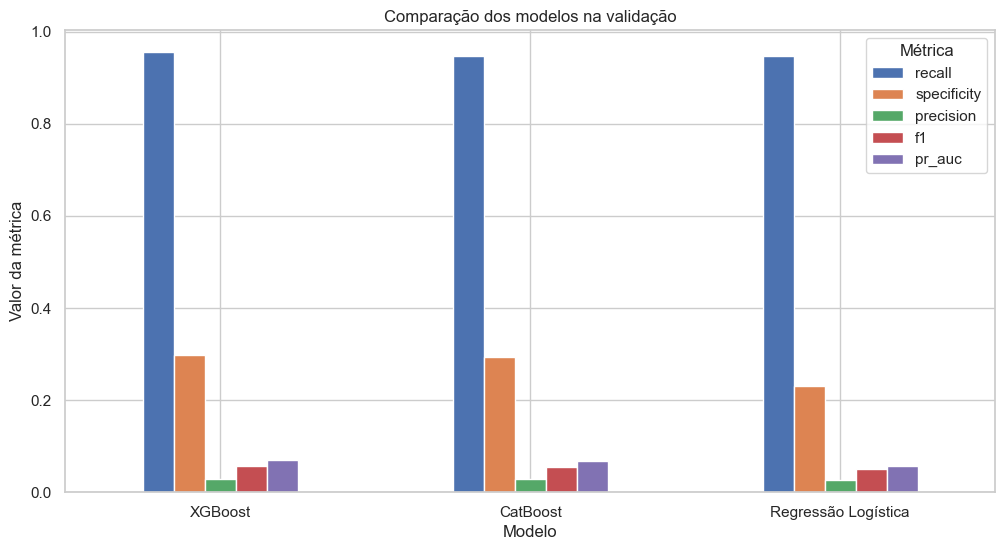

In [28]:
# Célula 69

def plotar_comparacao_modelos(resultados_modelos_df):
    base = resultados_modelos_df.set_index("modelo")[
        ["recall", "specificity", "precision", "f1", "pr_auc"]
    ]

    ax = base.plot(kind="bar", figsize=(12, 6))
    ax.set_title("Comparação dos modelos na validação")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Valor da métrica")
    plt.xticks(rotation=0)
    plt.legend(title="Métrica")
    plt.show()


plotar_comparacao_modelos(resultados_modelos_df)

## Célula 70

### Entendimento da saída

O ideal é que o melhor modelo mantenha **recall alto**, mas também apresente ganho em **specificity**, **precision** e **PR-AUC**.

Esse gráfico ajuda a mostrar que o melhor modelo não deve ser apenas o mais agressivo para prever sepse, e sim o que entrega o melhor equilíbrio clínico e operacional.

### Interpretação do gráfico: comparação dos modelos na validação

Este gráfico compara o desempenho dos modelos **XGBoost**, **CatBoost** e **Regressão Logística** no conjunto de validação, utilizando as métricas de **recall**, **specificity**, **precision**, **f1-score** e **PR AUC**.

O principal ponto observado é que os três modelos apresentam **recall muito alto**, próximo de 0,94 a 0,95. Isso mostra que todos conseguiram identificar a maior parte dos casos positivos de sepse, o que é especialmente importante neste projeto, já que reduzir falsos negativos é prioridade.

Por outro lado, a **precision é muito baixa em todos os modelos**, o que indica que, entre os casos classificados como sepse, muitos na verdade não eram positivos. Em outras palavras, os modelos estão conseguindo capturar os casos de sepse, mas ao custo de gerar muitos **falsos positivos**.

A **specificity** também é relativamente baixa, principalmente na Regressão Logística. Isso reforça que os modelos têm dificuldade em separar bem os casos sem sepse, classificando muitos pacientes negativos como positivos.

Comparando os modelos:
- **XGBoost** e **CatBoost** apresentaram desempenho muito parecido;
- ambos tiveram **specificity**, **f1** e **PR AUC** ligeiramente melhores do que a **Regressão Logística**;
- a **Regressão Logística** manteve recall alto, mas foi inferior no equilíbrio geral entre detectar sepse e evitar alarmes falsos.

O **PR AUC** e o **F1-score** permanecem baixos nos três modelos, o que é esperado em um problema altamente desbalanceado como este. Isso mostra que, embora o modelo esteja sensível para detectar sepse, ele ainda não tem boa precisão na separação entre as classes.

Em resumo, este gráfico mostra que:
**os três modelos priorizam sensibilidade, mas ainda apresentam muitos falsos positivos; entre eles, XGBoost e CatBoost tiveram o melhor equilíbrio geral na validação, com leve vantagem sobre a Regressão Logística.**

## Célula 71

### Entendimento da saída

Aqui você deve olhar principalmente:

- **FN**: precisa continuar baixo;
- **recall**: deve permanecer alto;
- **specificity**: precisa subir em relação às versões extremas;
- **taxa_alerta**: idealmente menor;
- **FP**: deve cair de forma relevante.

O melhor modelo não é o que parece “mais agressivo”, mas o que entrega o melhor equilíbrio para triagem.

## Célula 72

# Interpretação da comparação entre os modelos

A tabela acima deve ser lida na seguinte ordem:

1. verificar se o recall permaneceu alto o suficiente para triagem;
2. observar o volume de falsos negativos;
3. avaliar se houve ganho real de especificidade;
4. conferir a redução de falsos positivos e da taxa de alerta;
5. usar AUC-ROC e PR-AUC como métricas complementares.

O melhor modelo não é necessariamente o que zera FN, mas o que apresenta o melhor equilíbrio entre segurança clínica e utilidade operacional.

## Célula 73

# Seleção do melhor modelo

Agora selecionamos automaticamente o modelo com melhor desempenho segundo os critérios definidos anteriormente.

Esse modelo será usado na etapa final de avaliação no conjunto de teste, que representa a medição mais importante do experimento.

In [29]:
# Célula 74
melhor_nome_modelo = resultados_modelos_df.iloc[0]["modelo"]
melhor_modelo = artefatos_modelos[melhor_nome_modelo]["modelo"]
melhor_threshold = float(resultados_modelos_df.iloc[0]["threshold_base"])
curva_melhor_modelo = artefatos_modelos[melhor_nome_modelo]["resultados_threshold"].copy()

print("Melhor modelo:", melhor_nome_modelo)
print("Threshold base:", melhor_threshold)

Melhor modelo: XGBoost
Threshold base: 0.12


## Célula 75

### Entendimento da saída

Esta saída mostra:

- qual modelo venceu a comparação;
- qual threshold base será usado como primeira camada da triagem.

Esse threshold ainda não é o alerta final. Ele é a porta de entrada da triagem sensível.

## Célula 76

# Segunda camada clínica para reduzir falsos positivos

A primeira camada do sistema continuará sendo sensível, para captar pacientes suspeitos.

A segunda camada atuará como um refinamento clínico dos positivos, separando a saída em três estados:

- **sem_alerta**: paciente sem evidência suficiente de sepse;
- **monitorar**: paciente suspeito, mas ainda sem confirmação forte;
- **alerta_sepse**: paciente com maior coerência clínica e maior prioridade operacional.

A confirmação clínica levará em conta:

- probabilidade prevista pelo modelo;
- sinais clínicos relevantes;
- persistência temporal das alterações;
- score de risco clínico;
- score de disfunção orgânica.

## Célula 77

# Função auxiliar para criar séries nulas

Esta função cria uma série de zeros com o mesmo índice do dataframe.

Ela será usada quando alguma variável clínica não existir no dataset processado.

In [30]:
# Célula 78
def serie_zero(df):
    return pd.Series(0, index=df.index, dtype=int)

## Célula 79

### Entendimento da saída

Essa célula não gera saída visível.

Se ela rodar sem erro, a função auxiliar foi carregada corretamente.

## Célula 80

# Função auxiliar para criar flags clínicas robustas

Esta função tenta gerar uma flag binária a partir de:

- colunas já existentes;
- ou regras clínicas aplicadas diretamente nas variáveis brutas.

In [31]:
# Célula 81
def obter_flag(df, colunas=None, regra=None):
    colunas = colunas or []
    s = serie_zero(df)

    for col in colunas:
        if col in df.columns:
            s = np.maximum(s, (df[col].fillna(0).astype(float) > 0).astype(int))

    if regra is not None:
        try:
            s = np.maximum(s, regra(df).fillna(0).astype(int))
        except Exception:
            pass

    return pd.Series(s, index=df.index).astype(int)

## Célula 82

### Entendimento da saída

Essa função também não mostra tabela nem gráfico.

Ela serve para tornar a construção dos sinais clínicos mais segura, mesmo quando alguma coluna não estiver presente.

## Célula 83

# Construção dos sinais clínicos confirmatórios

Agora agrupamos os principais sinais que sustentam a hipótese de sepse na segunda camada do sistema.

In [32]:
# Célula 84
def construir_sinais_confirmatorios(df):
    sinais = pd.DataFrame(index=df.index)

    sinais["hipotensao_map"] = obter_flag(
        df,
        colunas=["flag_hipotensao_map"],
        regra=lambda x: (x["MAP"] < 65).astype(int) if "MAP" in x.columns else serie_zero(x)
    )

    sinais["taquipneia"] = obter_flag(
        df,
        colunas=["flag_taquipneia"],
        regra=lambda x: (x["Resp"] > 22).astype(int) if "Resp" in x.columns else serie_zero(x)
    )

    sinais["taquicardia"] = obter_flag(
        df,
        colunas=["flag_taquicardia"],
        regra=lambda x: (x["HR"] > 100).astype(int) if "HR" in x.columns else serie_zero(x)
    )

    sinais["lactato_alto"] = obter_flag(
        df,
        colunas=["flag_lactato_alto"],
        regra=lambda x: (x["Lactate"] >= 2).astype(int) if "Lactate" in x.columns else serie_zero(x)
    )

    sinais["disfuncao_renal"] = obter_flag(
        df,
        colunas=["flag_disfuncao_renal"],
        regra=lambda x: (x["Creatinine"] > 1.2).astype(int) if "Creatinine" in x.columns else serie_zero(x)
    )

    sinais["hipoxemia"] = obter_flag(
        df,
        colunas=["flag_hipoxemia"],
        regra=lambda x: (x["O2Sat"] < 92).astype(int) if "O2Sat" in x.columns else serie_zero(x)
    )

    sinais["temperatura_alterada"] = obter_flag(
        df,
        colunas=["flag_febre", "flag_hipotermia"],
        regra=lambda x: (((x["Temp"] >= 38) | (x["Temp"] < 36)).astype(int)) if "Temp" in x.columns else serie_zero(x)
    )

    sinais["wbc_alterado"] = obter_flag(
        df,
        colunas=["flag_leucocitos_alterados"],
        regra=lambda x: (((x["WBC"] > 12) | (x["WBC"] < 4)).astype(int)) if "WBC" in x.columns else serie_zero(x)
    )

    return sinais

## Célula 85

### Entendimento da saída

Essa função organiza os sinais clínicos usados como confirmação.

Ela não precisa mostrar nada agora. O valor dela aparece quando a segunda camada começar a filtrar os positivos fracos.

## Célula 86

# Aplicação da segunda camada de triagem

Esta função transforma a saída do modelo em três estados:

- **sem_alerta**
- **monitorar**
- **alerta_sepse**

Ela usa:

- threshold base sensível;
- threshold alto de confirmação;
- sinais clínicos;
- persistência temporal;
- scores compostos.

In [33]:
# Célula 87
def aplicar_segunda_camada_triagem(df, y_prob, th_baixo, th_alto=0.25, min_sinais=2):
    df = df.copy()
    y_prob = np.asarray(y_prob)

    pred_base = (y_prob >= th_baixo).astype(int)
    sinais = construir_sinais_confirmatorios(df)
    qtd_sinais_confirmatorios = sinais.sum(axis=1)

    colunas_persistencia = [
        "flag_map_baixa_count_3h",
        "flag_map_baixa_count_6h",
        "flag_map_baixa_count_12h",
        "flag_taquipneia_22_count_3h",
        "flag_taquipneia_22_count_6h",
        "flag_taquipneia_22_count_12h",
        "flag_taquicardia_100_count_3h",
        "flag_taquicardia_100_count_6h",
        "flag_taquicardia_100_count_12h",
        "flag_lactato_alto_2_count_6h",
        "flag_lactato_alto_2_count_12h",
        "flag_creatinina_alta_count_6h",
        "flag_creatinina_alta_count_12h",
    ]

    persistencias = []
    for col in colunas_persistencia:
        if col in df.columns:
            persistencias.append((df[col].fillna(0) >= 2).astype(int))

    if persistencias:
        persistencia_clinica = pd.concat(persistencias, axis=1).max(axis=1).astype(int)
    else:
        persistencia_clinica = serie_zero(df)

    organica_grave = (
        (df["organ_dysfunction_score"] >= 3).astype(int)
        if "organ_dysfunction_score" in df.columns else serie_zero(df)
    )

    risco_clinico_alto = (
        (df["clinical_risk_score"] >= 3).astype(int)
        if "clinical_risk_score" in df.columns else serie_zero(df)
    )

    pred_base_series = pd.Series(pred_base, index=df.index)

    if "patient_id" in df.columns:
        alerta_persistente = pred_base_series.groupby(df["patient_id"]).transform(
            lambda s: (s.rolling(3, min_periods=1).sum() >= 2).astype(int)
        )
    else:
        alerta_persistente = pred_base_series.copy()

    confirmacao_clinica = (
        ((qtd_sinais_confirmatorios >= min_sinais) & (persistencia_clinica == 1)) |
        (organica_grave == 1) |
        (risco_clinico_alto == 1)
    ).astype(int)

    pred_final = np.where(
        pred_base == 1,
        ((y_prob >= th_alto) | ((alerta_persistente == 1) & (confirmacao_clinica == 1))).astype(int),
        0
    )

    status_triagem = np.select(
        [pred_final == 1, pred_base == 1],
        ["alerta_sepse", "monitorar"],
        default="sem_alerta"
    )

    return pd.DataFrame({
        "prob_sepse": y_prob,
        "pred_base": pred_base,
        "pred_final": pred_final.astype(int),
        "qtd_sinais_confirmatorios": qtd_sinais_confirmatorios.astype(int),
        "persistencia_clinica": persistencia_clinica.astype(int),
        "organica_grave": organica_grave.astype(int),
        "risco_clinico_alto": risco_clinico_alto.astype(int),
        "alerta_persistente": alerta_persistente.astype(int),
        "status_triagem": status_triagem
    }, index=df.index)

## Célula 88

### Entendimento da saída

Aqui nasce a lógica principal da triagem em duas etapas.

A interpretação é:

- **pred_base** = triagem sensível;
- **pred_final** = alerta forte após confirmação;
- **status_triagem** = saída operacional final.

## Célula 89

# Busca da melhor configuração da segunda camada

Agora testamos várias combinações de:

- threshold baixo;
- threshold alto;
- quantidade mínima de sinais clínicos.

Tudo isso é ajustado somente na validação.

In [34]:
# Célula 90
def buscar_melhor_segunda_camada(
    y_true,
    y_prob,
    df_base,
    thresholds_baixos=np.arange(0.03, 0.21, 0.01),
    thresholds_altos=np.arange(0.15, 0.46, 0.05),
    mins_sinais=(1, 2, 3),
    recall_min=0.94,
    fn_max_ratio=0.06,
):
    y_true = np.asarray(y_true)
    total_positivos = int((y_true == 1).sum())
    fn_max_abs = max(1, int(total_positivos * fn_max_ratio))

    resultados = []

    for th_baixo in thresholds_baixos:
        for th_alto in thresholds_altos:
            if th_alto <= th_baixo:
                continue

            for min_sinais in mins_sinais:
                saida = aplicar_segunda_camada_triagem(
                    df=df_base,
                    y_prob=y_prob,
                    th_baixo=th_baixo,
                    th_alto=th_alto,
                    min_sinais=min_sinais
                )

                metricas = calcular_metricas_binarias(
                    y_true=y_true,
                    y_pred=saida["pred_final"].astype(int).values
                )

                resultados.append({
                    "th_baixo": float(th_baixo),
                    "th_alto": float(th_alto),
                    "min_sinais": int(min_sinais),
                    **metricas
                })

    resultados_df = pd.DataFrame(resultados)

    candidatos = resultados_df[
        (resultados_df["recall"] >= recall_min) &
        (resultados_df["FN"] <= fn_max_abs)
    ].copy()

    if candidatos.empty:
        candidatos = resultados_df.sort_values(
            by=["FN", "recall", "specificity", "precision", "FP", "taxa_alerta"],
            ascending=[True, False, False, False, True, True]
        ).head(20).copy()

    melhor = candidatos.sort_values(
        by=["FP", "taxa_alerta", "specificity", "precision", "th_alto", "min_sinais"],
        ascending=[True, True, False, False, False, False]
    ).iloc[0]

    return melhor, resultados_df

## Célula 91

### Entendimento da saída

Essa função também não mostra nada sozinha.

Ela prepara a etapa em que vamos escolher a configuração final da segunda camada sem usar o teste.

## Célula 92

# Ajuste da segunda camada na validação

Agora aplicamos a busca da segunda camada usando o melhor modelo escolhido anteriormente.

In [35]:
# Célula 93
y_prob_val_melhor = artefatos_modelos[melhor_nome_modelo]["y_prob_val"]

melhor_filtro, resultados_filtro = buscar_melhor_segunda_camada(
    y_true=y_val,
    y_prob=y_prob_val_melhor,
    df_base=df_val_feat,
    thresholds_baixos=np.arange(0.03, 0.21, 0.01),
    thresholds_altos=np.arange(0.15, 0.46, 0.05),
    mins_sinais=(1, 2, 3),
    recall_min=0.94,
    fn_max_ratio=0.06
)

display(
    resultados_filtro.sort_values(
        by=["FN", "FP", "specificity", "precision"],
        ascending=[True, True, False, False]
    ).head(10)
)

print("Melhor configuração da segunda camada:")
print(melhor_filtro)

,th_baixo,th_alto,min_sinais,TN,FP,FN,TP,precision,recall,specificity,f1,taxa_alerta
0,0.03,0.15,1,35064,120605,151,3275,0.026437,0.955925,0.225247,0.051451,0.778654
21,0.04,0.15,1,35591,120078,154,3272,0.026526,0.955050,0.228633,0.051619,0.775323
42,0.05,0.15,1,36841,118828,157,3269,0.026774,0.954174,0.236662,0.052086,0.767447
63,0.06,0.15,1,38898,116771,161,3265,0.027200,0.953006,0.249876,0.052891,0.754493
84,0.07,0.15,1,41463,114206,167,3259,0.027744,0.951255,0.266354,0.053916,0.738332
105,0.08,0.15,1,44365,111304,174,3252,0.028388,0.949212,0.284996,0.055127,0.720048
126,0.09,0.15,1,47527,108142,186,3240,0.029089,0.945709,0.305308,0.056442,0.700097
147,0.10,0.15,1,50631,105038,199,3227,0.029806,0.941915,0.325248,0.057784,0.680505
1,0.03,0.15,2,41570,114099,210,3216,0.027413,0.938704,0.267041,0.053271,0.737390
22,0.04,0.15,2,41996,113673,213,3213,0.027488,0.937828,0.269778,0.053411,0.734693


Melhor configuração da segunda camada:
th_baixo            0.100000
th_alto             0.150000
min_sinais          1.000000
TN              50631.000000
FP             105038.000000
FN                199.000000
TP               3227.000000
precision           0.029806
recall              0.941915
specificity         0.325248
f1                  0.057784
taxa_alerta         0.680505
Name: 147, dtype: float64


## Célula 94

# Heatmap da segunda camada clínica

A tabela de combinações testadas é útil, mas o heatmap facilita a visualização de quais pares de thresholds geram menos falsos positivos na segunda camada.

O gráfico será mostrado para o valor de `min_sinais` escolhido como melhor configuração.

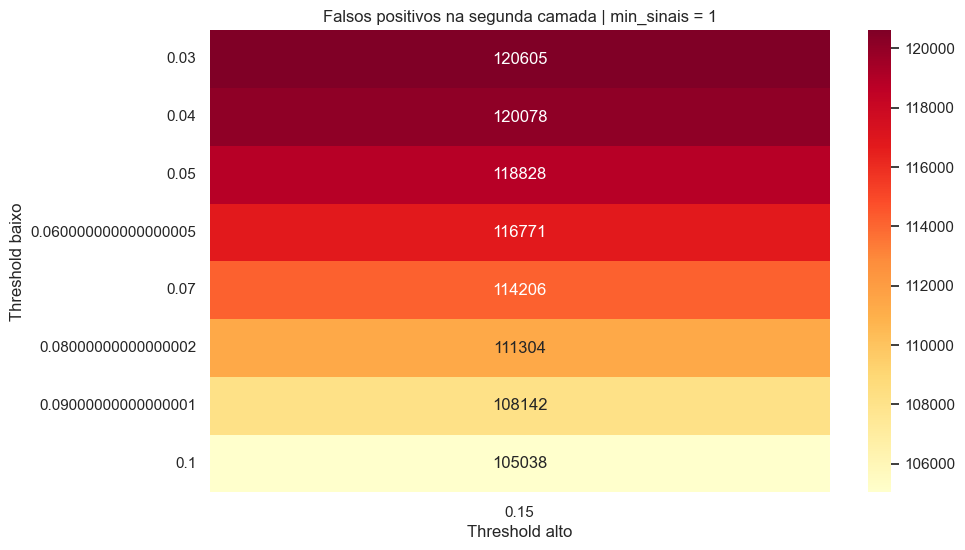

In [36]:
# Célula 95

def plotar_heatmap_segunda_camada(resultados_filtro, min_sinais_escolhido):
    base = resultados_filtro[
        (resultados_filtro["min_sinais"] == min_sinais_escolhido) &
        (resultados_filtro["recall"] >= 0.94)
    ].copy()

    if base.empty:
        base = resultados_filtro[
            resultados_filtro["min_sinais"] == min_sinais_escolhido
        ].copy()

    pivot = base.pivot_table(
        index="th_baixo",
        columns="th_alto",
        values="FP",
        aggfunc="min"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
    plt.title(f"Falsos positivos na segunda camada | min_sinais = {min_sinais_escolhido}")
    plt.xlabel("Threshold alto")
    plt.ylabel("Threshold baixo")
    plt.show()


plotar_heatmap_segunda_camada(
    resultados_filtro,
    int(melhor_filtro["min_sinais"])
)

## Célula 96

### Entendimento da saída

As regiões com menor quantidade de **FP** são mais interessantes, desde que o **recall** continue dentro do limite definido.

Esse gráfico ajuda a mostrar visualmente que a escolha da segunda camada não foi arbitrária. Ela foi baseada em uma combinação que reduz alertas desnecessários sem perder segurança clínica.

### Interpretação do gráfico: falsos positivos na segunda camada

Este gráfico mostra a quantidade de **falsos positivos (FP)** gerados pela **segunda camada de decisão**, mantendo o **threshold alto fixo em 0.15** e **min_sinais = 1**, enquanto o **threshold baixo** varia de 0.03 até 0.10.

O que o gráfico mostra de forma clara é que, à medida que o **threshold baixo aumenta**, a quantidade de falsos positivos **diminui continuamente**. Por exemplo:
- com **threshold baixo = 0.03**, os falsos positivos são **120.605**;
- com **threshold baixo = 0.10**, os falsos positivos caem para **105.038**.

Isso significa que tornar a segunda camada mais rigorosa no threshold baixo reduz a quantidade de pacientes sem sepse que estão sendo classificados como positivos.

O gráfico também mostra que essa redução ocorre de forma relativamente estável, sem saltos bruscos, indicando que o threshold baixo tem impacto direto e previsível sobre os falsos positivos.

Em termos práticos, entendemos que:
- thresholds baixos mais permissivos fazem a segunda camada disparar mais alertas;
- thresholds baixos mais altos tornam a regra mais seletiva;
- portanto, aumentar esse threshold é uma forma direta de controlar o excesso de falsos positivos.

No entanto, essa análise deve ser interpretada junto com os **falsos negativos (FN)**, porque reduzir FP isoladamente não significa melhorar o modelo de forma geral. Em problemas médicos, especialmente neste caso, não basta diminuir alarmes falsos: é necessário verificar se esse ganho não está fazendo o modelo deixar mais casos reais de sepse passarem.

Em resumo, este gráfico indica que:
**o aumento do threshold baixo na segunda camada reduz progressivamente os falsos positivos, tornando a regra mais conservadora, mas essa escolha só é adequada se os falsos negativos permanecerem sob controle.**

## Célula 97

### Entendimento da saída

Aqui você deve observar:

- se o **FN** continua controlado;
- se o **FP** caiu;
- se a **specificity** subiu;
- qual combinação de `th_baixo`, `th_alto` e `min_sinais` ficou mais interessante.

Essa saída define a configuração final da triagem refinada.

## Célula 98

# Comportamento do threshold no melhor modelo

Nesta etapa visualizamos como a quantidade de falsos negativos, falsos positivos e verdadeiros positivos varia conforme o threshold muda.

Esse gráfico ajuda a justificar de forma visual a escolha do threshold final, mostrando o ponto em que o modelo preserva sensibilidade sem elevar desnecessariamente o volume de alertas.

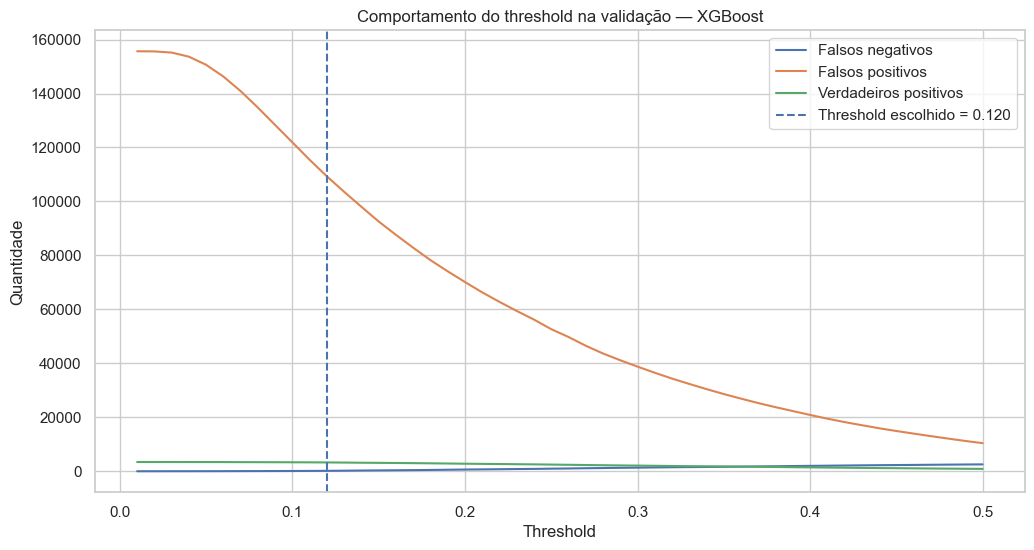

In [37]:
# Célula 99
plt.figure(figsize=(12, 6))
plt.plot(curva_melhor_modelo["threshold"], curva_melhor_modelo["FN"], label="Falsos negativos")
plt.plot(curva_melhor_modelo["threshold"], curva_melhor_modelo["FP"], label="Falsos positivos")
plt.plot(curva_melhor_modelo["threshold"], curva_melhor_modelo["TP"], label="Verdadeiros positivos")
plt.axvline(melhor_threshold, linestyle="--", label=f"Threshold escolhido = {melhor_threshold:.3f}")
plt.title(f"Comportamento do threshold na validação — {melhor_nome_modelo}")
plt.xlabel("Threshold")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

## Célula 100

# Interpretação do gráfico de threshold

O gráfico permite visualizar o trade-off entre sensibilidade e volume de alertas.

A leitura principal deve observar em que ponto os falsos negativos começam a aumentar e se existe uma faixa em que ainda seja possível manter boa sensibilidade com alguma redução dos falsos positivos.

A conclusão desta etapa deve explicar por que o threshold escolhido foi considerado o mais adequado para o objetivo do projeto.

### Interpretação do gráfico: comportamento do threshold na validação — XGBoost

Este gráfico mostra como a escolha do **threshold de decisão** impacta a quantidade de **falsos negativos (FN)**, **falsos positivos (FP)** e **verdadeiros positivos (TP)** no conjunto de validação do modelo XGBoost.

A curva de **falsos positivos** é a que mais se destaca. Ela começa muito alta nos thresholds mais baixos e vai caindo de forma contínua conforme o threshold aumenta. Isso indica que, quando o modelo é mais permissivo, ele classifica muitos casos como sepse, gerando um grande número de alarmes falsos. À medida que o threshold sobe, o modelo fica mais seletivo e os falsos positivos diminuem bastante.

A curva de **falsos negativos** segue o comportamento oposto: ela começa muito baixa e tende a aumentar conforme o threshold aumenta. Isso acontece porque um threshold mais alto exige maior confiança para classificar um caso como positivo, o que reduz falsos alarmes, mas aumenta o risco de deixar passar casos reais de sepse.

Já a curva de **verdadeiros positivos** apresenta queda gradual com o aumento do threshold. Isso mostra que, ao tornar o critério mais rígido, o modelo também deixa de identificar parte dos casos positivos reais.

A linha tracejada marca o **threshold escolhido de 0.120**. Esse ponto representa um compromisso entre dois objetivos conflitantes:
manter os **falsos negativos baixos**, que é a prioridade clínica do problema, e ao mesmo tempo começar a reduzir os **falsos positivos**, que estavam muito altos em thresholds mais baixos.

Portanto, o gráfico mostra de forma clara que a escolha do threshold não é arbitrária. Ela define o equilíbrio entre:
- **maior sensibilidade** para detectar sepse;
- **menor quantidade de alarmes falsos**.

Em resumo, este gráfico indica que:
**thresholds baixos favorecem a detecção de sepse, mas geram muitos falsos positivos; thresholds mais altos reduzem falsos positivos, mas aumentam o risco de perder casos reais. O valor 0.120 foi escolhido como um ponto de equilíbrio na validação.**

## Célula 101

# Avaliação final no conjunto de teste

Depois de escolher o melhor modelo e o melhor threshold com base na validação, aplicamos essa configuração ao conjunto de teste.

Essa etapa representa a avaliação final do pipeline em dados que não participaram da escolha do modelo nem da escolha do threshold.

## Célula 102

Agora aplicamos no teste:

- o melhor modelo;
- o threshold base;
- a melhor configuração da segunda camada.

Vamos medir separadamente:

- a saída da triagem sensível;
- a saída do alerta forte.

In [38]:
# Célula 103
y_prob_test = melhor_modelo.predict_proba(X_test)[:, 1]

saida_test = aplicar_segunda_camada_triagem(
    df=df_test_feat,
    y_prob=y_prob_test,
    th_baixo=float(melhor_filtro["th_baixo"]),
    th_alto=float(melhor_filtro["th_alto"]),
    min_sinais=int(melhor_filtro["min_sinais"])
)

y_pred_triagem = saida_test["pred_base"].astype(int).values
y_pred_alerta = saida_test["pred_final"].astype(int).values

metricas_teste = pd.DataFrame([
    {
        "saida": "triagem_sensivel",
        **calcular_metricas_binarias(y_test, y_pred_triagem),
        "roc_auc": float(roc_auc_score(y_test, y_prob_test)),
        "pr_auc": float(average_precision_score(y_test, y_prob_test)),
    },
    {
        "saida": "alerta_forte",
        **calcular_metricas_binarias(y_test, y_pred_alerta),
        "roc_auc": float(roc_auc_score(y_test, y_prob_test)),
        "pr_auc": float(average_precision_score(y_test, y_prob_test)),
    }
])

display(metricas_teste)
print(saida_test["status_triagem"].value_counts(dropna=False))

,saida,TN,FP,FN,TP,precision,recall,specificity,f1,taxa_alerta,roc_auc,pr_auc
0,triagem_sensivel,208786,542429,1131,9649,0.017478,0.895083,0.277931,0.034286,0.724517,0.716505,0.048082
1,alerta_forte,329604,421611,1791,8989,0.020876,0.833859,0.438761,0.040731,0.565096,0.716505,0.048082


status_triagem
alerta_sepse    430600
sem_alerta      209917
monitorar       121478
Name: count, dtype: int64


## Célula 104

# Comparação das métricas finais entre triagem sensível e alerta forte

Nesta etapa comparamos as duas saídas finais do sistema no conjunto de teste.

A triagem sensível representa a porta de entrada mais ampla. O alerta forte representa a saída mais restritiva e mais coerente clinicamente.

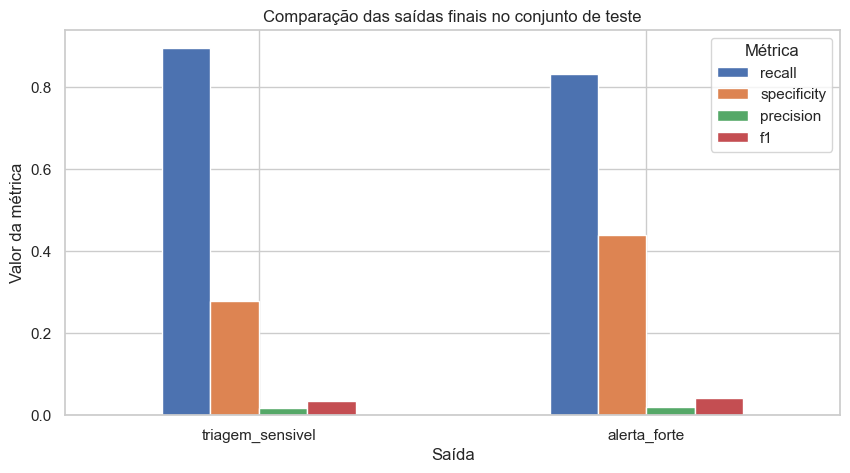

In [39]:
# Célula 105

def plotar_metricas_finais(metricas_teste):
    base = metricas_teste.set_index("saida")[
        ["recall", "specificity", "precision", "f1"]
    ]

    ax = base.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Comparação das saídas finais no conjunto de teste")
    ax.set_xlabel("Saída")
    ax.set_ylabel("Valor da métrica")
    plt.xticks(rotation=0)
    plt.legend(title="Métrica")
    plt.show()


plotar_metricas_finais(metricas_teste)

## Célula 106

### Entendimento da saída

Espera-se que a **triagem sensível** apresente maior recall, enquanto o **alerta forte** apresente melhor especificidade e precisão.

Esse gráfico deixa claro o papel de cada saída: uma mais sensível para captar suspeitos e outra mais criteriosa para reduzir falsos positivos.

### Interpretação do gráfico: comparação das saídas finais no conjunto de teste

Este gráfico compara o desempenho das duas saídas finais do pipeline no conjunto de teste: **triagem_sensivel** e **alerta_forte**, usando as métricas de **recall**, **specificity**, **precision** e **f1-score**.

O principal ponto observado é que a **triagem_sensivel** apresenta **recall mais alto**, enquanto o **alerta_forte** apresenta **specificity, precision e f1-score melhores**. Isso mostra que as duas saídas foram construídas com objetivos diferentes.

A **triagem_sensivel** foi desenhada para ser mais permissiva, tentando capturar o maior número possível de casos de sepse. Por isso, ela alcança maior sensibilidade, mas ao custo de classificar mais pacientes sem sepse como positivos. Em termos práticos, ela é mais útil como uma etapa inicial de rastreio, em que o foco é reduzir o risco de deixar passar casos verdadeiros.

Já o **alerta_forte** é mais restritivo. Ele reduz parte dos alarmes falsos, o que melhora a **specificity** e eleva um pouco a **precision** e o **f1-score**. No entanto, essa melhora vem acompanhada de queda no **recall**, ou seja, alguns casos reais de sepse deixam de ser identificados nessa saída mais rígida.

O gráfico, portanto, evidencia um **trade-off clínico e estatístico**:
- a **triagem_sensivel** prioriza detectar mais casos reais;
- o **alerta_forte** prioriza emitir alertas mais seletivos e menos ruidosos.

Mesmo com a melhora do **alerta_forte**, a **precision continua muito baixa** em ambas as saídas. Isso indica que o modelo ainda gera muitos falsos positivos no teste, mesmo após a segunda camada de decisão. Ou seja, houve ganho de seletividade, mas o problema de excesso de alertas ainda não foi totalmente resolvido.

Em resumo, este gráfico mostra que:
**a saída triagem_sensivel é mais adequada quando a prioridade máxima é não perder casos de sepse, enquanto a saída alerta_forte oferece um equilíbrio melhor entre sensibilidade e controle de alarmes falsos, embora ainda com baixa precisão geral.**

## Célula 107

### Entendimento da saída

Agora você terá duas leituras:

- **triagem_sensivel**: deve manter recall mais alto;
- **alerta_forte**: deve reduzir FP e organizar melhor a prioridade.

O objetivo não é que as duas saídas sejam iguais.
A utilidade está justamente em separar captação sensível de confirmação forte.

## Célula 108

# Interpretação das métricas finais

A tabela acima resume o desempenho final do modelo no conjunto de teste.

A leitura principal deve destacar:

- quantos falsos negativos permaneceram;
- quantos falsos positivos foram gerados;
- se o comportamento do modelo é mais compatível com uma ferramenta de triagem do que com um diagnóstico definitivo.

Essa interpretação é central para sustentar a utilidade prática do sistema no contexto clínico.

## Célula 109

# Matriz de confusão

A matriz de confusão facilita a visualização direta dos acertos e erros do modelo.

No contexto deste projeto, ela é especialmente importante porque mostra de forma explícita se o modelo está deixando passar casos de sepse, além de revelar o custo disso em termos de falsos alertas.

## Célula 110

# Matrizes de confusão das duas saídas

Agora vamos visualizar separadamente a matriz da triagem sensível e a matriz do alerta forte.

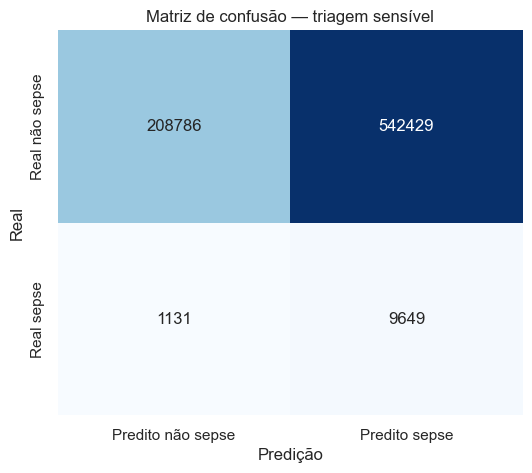

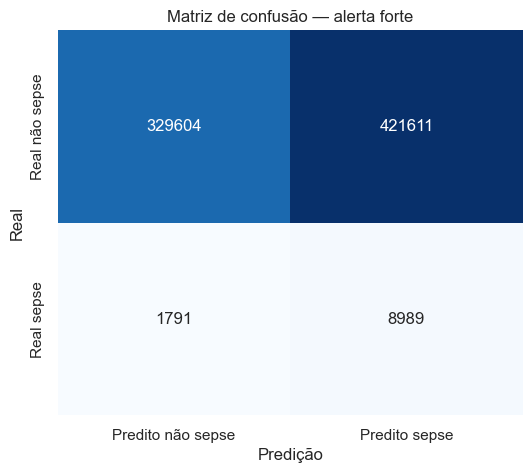

In [40]:
# Célula 111
cm_triagem = confusion_matrix(y_test, y_pred_triagem, labels=[0, 1])
cm_alerta = confusion_matrix(y_test, y_pred_alerta, labels=[0, 1])

for titulo, cm in [
    ("Matriz de confusão — triagem sensível", cm_triagem),
    ("Matriz de confusão — alerta forte", cm_alerta),
]:
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predito não sepse", "Predito sepse"],
        yticklabels=["Real não sepse", "Real sepse"]
    )
    plt.title(titulo)
    plt.xlabel("Predição")
    plt.ylabel("Real")
    plt.show()

### Interpretação das matrizes de confusão — conjunto de teste

As duas matrizes mostram o desempenho final do pipeline no conjunto de teste, comparando as saídas **triagem sensível** e **alerta forte**.

#### 1. Matriz de confusão — triagem sensível

Na saída **triagem sensível**, os resultados foram:
- **TN (verdadeiros negativos): 208.786**
- **FP (falsos positivos): 542.429**
- **FN (falsos negativos): 1.131**
- **TP (verdadeiros positivos): 9.649**

Essa matriz mostra que a triagem sensível conseguiu identificar a maior parte dos casos reais de sepse, com **recall em torno de 89,5%**, o que é coerente com a proposta de uma etapa inicial mais sensível. Em contrapartida, o número de **falsos positivos é extremamente alto**, indicando que muitos pacientes sem sepse foram classificados como positivos.

Isso significa que essa saída é útil quando o objetivo principal é **não deixar passar muitos casos reais**, mas ela gera um volume muito grande de alertas falsos. Na prática, funciona melhor como uma **triagem inicial**, e não como decisão clínica final isolada.

#### 2. Matriz de confusão — alerta forte

Na saída **alerta forte**, os resultados foram:
- **TN (verdadeiros negativos): 329.604**
- **FP (falsos positivos): 421.611**
- **FN (falsos negativos): 1.791**
- **TP (verdadeiros positivos): 8.989**

Comparada à triagem sensível, essa saída conseguiu **reduzir os falsos positivos em 120.818 casos**, o que representa uma melhora importante na seletividade. Além disso, aumentou bastante os verdadeiros negativos, mostrando que a segunda camada conseguiu filtrar melhor parte dos alarmes indevidos.

Por outro lado, essa melhora veio acompanhada de aumento dos **falsos negativos**, que subiram de **1.131 para 1.791**. Isso significa que o modelo passou a deixar escapar mais casos reais de sepse. O **recall caiu para cerca de 83,4%**, enquanto a **specificity subiu para cerca de 43,9%**.

#### 3. O que entendemos ao comparar as duas matrizes

As matrizes deixam claro o principal trade-off do modelo:

- a **triagem sensível** detecta mais casos reais de sepse;
- o **alerta forte** reduz parte dos alarmes falsos;
- porém, ao reduzir FP, o alerta forte também aumenta FN.

Em outras palavras, a segunda camada realmente melhora a capacidade de filtrar pacientes sem sepse, mas ainda não resolve o problema de forma completa, porque o número de falsos positivos continua muito alto e o custo dessa filtragem é perder mais pacientes com sepse.

#### 4. Conclusão prática

Essas matrizes mostram que o pipeline está operando em dois níveis:

A **triagem sensível** é mais adequada como ferramenta de rastreio, quando a prioridade é maximizar a detecção de casos suspeitos, mesmo com muito ruído.

O **alerta forte** é mais adequado como uma saída mais restritiva, que tenta reduzir parte dos alertas indevidos, mas ainda não atinge um equilíbrio ideal para uso confiável como decisão final independente.

Em resumo, as matrizes confirmam que:
**o modelo consegue capturar boa parte dos casos de sepse, mas ainda sofre com excesso de falsos positivos; a segunda camada melhora esse cenário, porém ao custo de aumentar os falsos negativos.**

## Célula 112

# Matrizes de confusão normalizadas

Além da matriz absoluta, a versão normalizada mostra a proporção de acertos e erros dentro de cada classe real.

Isso melhora a leitura em problemas desbalanceados.

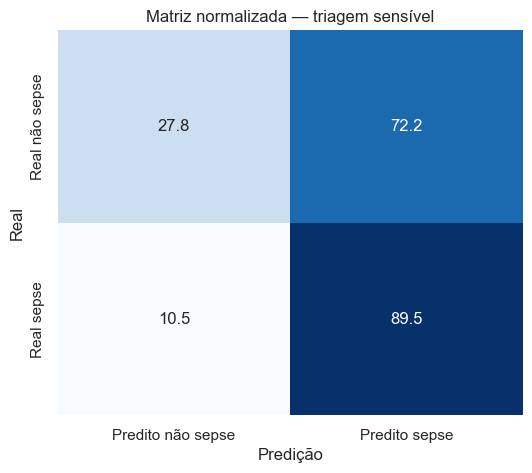

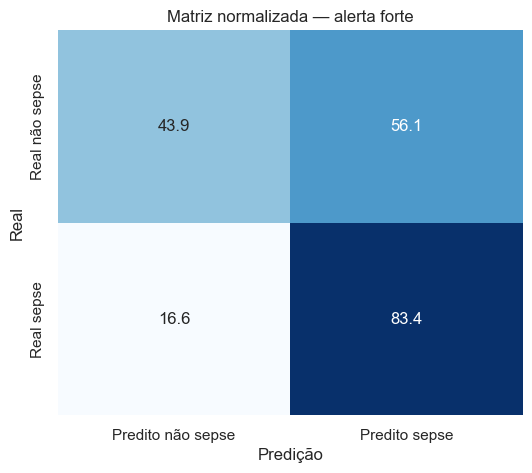

In [41]:
# Célula 113

def plotar_matriz_normalizada(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, normalize="true") * 100

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predito não sepse", "Predito sepse"],
        yticklabels=["Real não sepse", "Real sepse"]
    )
    plt.title(titulo)
    plt.xlabel("Predição")
    plt.ylabel("Real")
    plt.show()


plotar_matriz_normalizada(y_test, y_pred_triagem, "Matriz normalizada — triagem sensível")
plotar_matriz_normalizada(y_test, y_pred_alerta, "Matriz normalizada — alerta forte")

## Célula 114

### Entendimento da saída

Aqui cada linha representa 100% dos casos reais daquela classe.

Isso ajuda a enxergar com mais clareza:
- quanto da classe com sepse foi corretamente capturado;
- quanto da classe sem sepse foi confundido com sepse;
- e como a triagem sensível se compara ao alerta forte em termos proporcionais.

### Interpretação das matrizes normalizadas — conjunto de teste

As matrizes normalizadas mostram o desempenho do modelo em **percentual dentro de cada classe real**, o que facilita entender a proporção de acertos e erros para pacientes **sem sepse** e **com sepse**.

#### 1. Matriz normalizada — triagem sensível

Na **triagem sensível**:
- **27,8%** dos pacientes que realmente **não tinham sepse** foram corretamente classificados como **não sepse**;
- **72,2%** dos pacientes que realmente **não tinham sepse** foram classificados como **sepse**;
- **89,5%** dos pacientes que realmente **tinham sepse** foram corretamente classificados como **sepse**;
- **10,5%** dos pacientes que realmente **tinham sepse** foram classificados como **não sepse**.

Isso mostra que a triagem sensível é, de fato, uma saída mais voltada para **capturar casos positivos**, pois acerta uma parcela alta dos pacientes com sepse. No entanto, ela faz isso ao custo de um erro muito elevado na classe sem sepse, classificando a maioria dos pacientes negativos como positivos.

#### 2. Matriz normalizada — alerta forte

No **alerta forte**:
- **43,9%** dos pacientes que realmente **não tinham sepse** foram corretamente classificados como **não sepse**;
- **56,1%** dos pacientes que realmente **não tinham sepse** foram classificados como **sepse**;
- **83,4%** dos pacientes que realmente **tinham sepse** foram corretamente classificados como **sepse**;
- **16,6%** dos pacientes que realmente **tinham sepse** foram classificados como **não sepse**.

Aqui vemos que o alerta forte melhora a identificação dos pacientes sem sepse, reduzindo a proporção de falsos positivos. Porém, essa melhora vem acompanhada de piora na classe com sepse, pois aumenta a proporção de falsos negativos.

#### 3. Comparação entre as duas saídas

Comparando as duas matrizes, entendemos que:

- a **triagem sensível** tem melhor desempenho para **detectar sepse**;
- o **alerta forte** tem melhor desempenho para **evitar parte dos alarmes falsos**;
- a melhora na classe sem sepse do alerta forte acontece com perda de sensibilidade na classe com sepse.

Em termos percentuais:
- a taxa de acerto dos pacientes **sem sepse** sobe de **27,8% para 43,9%**;
- a taxa de acerto dos pacientes **com sepse** cai de **89,5% para 83,4%**.

#### 4. O que entendemos desses gráficos

Essas matrizes deixam muito claro o comportamento do pipeline:

- a **triagem sensível** é melhor quando a prioridade é **maximizar a detecção de sepse**;
- o **alerta forte** é melhor quando se quer **reduzir parte do excesso de alertas**, mesmo aceitando perder mais casos reais.

A principal conclusão é que a segunda camada melhora a seletividade, mas ainda não atinge um equilíbrio ideal, porque mesmo no alerta forte mais da metade dos pacientes sem sepse ainda é classificada como positiva.

#### 5. Conclusão

Em resumo, os gráficos mostram que:
**a triagem sensível prioriza recall e identifica melhor os casos de sepse, enquanto o alerta forte melhora a especificidade, mas aumenta a perda de casos reais.**

## Célula 115

### Entendimento da saída

A matriz da **triagem sensível** deve mostrar maior capacidade de captar suspeitos.

A matriz do **alerta forte** deve mostrar melhor utilidade operacional, com menos falsos positivos.

Se as duas ficarem quase iguais, a segunda camada não está refinando o suficiente.

## Célula 116

# Interpretação da matriz de confusão

A principal leitura desta matriz é verificar se o modelo conseguiu manter a prioridade clínica do projeto, que é reduzir ao máximo os falsos negativos.

Ao mesmo tempo, ela mostra o custo dessa decisão em termos de falsos positivos. Essa análise ajuda a posicionar o sistema como ferramenta de apoio à triagem clínica, e não como substituto da decisão médica.

## Célula 117

# Importância das features

Depois da avaliação final, analisamos quais variáveis mais influenciaram as previsões do modelo.

Essa etapa é importante para verificar se o algoritmo está aprendendo padrões clinicamente coerentes, como alterações de lactato, pressão arterial, frequência respiratória, oxigenação e sinais de disfunção orgânica.

,feature,importance
79,sirs_score,0.123386
231,Temp_max3,0.027033
78,qtd_sinais_alterados,0.025276
82,clinical_risk_score,0.022140
37,Unit2,0.019096
112,Temp_worst_6h,0.016581
88,flag_lactato_normal,0.014229
2,Temp,0.013433
36,Unit1,0.012884
135,Resp_mean_12h,0.012215


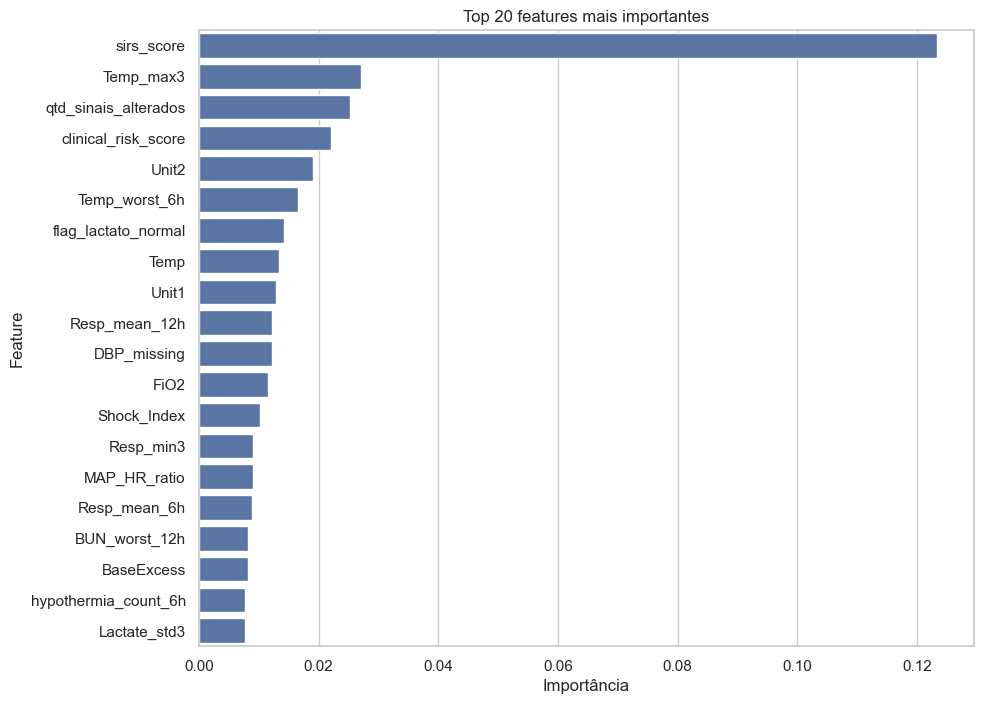

In [42]:
# Célula 118
if hasattr(melhor_modelo, "feature_importances_"):
    importancia = pd.DataFrame({
        "feature": features,
        "importance": melhor_modelo.feature_importances_
    }).sort_values("importance", ascending=False).head(20)

elif hasattr(melhor_modelo, "named_steps") and "clf" in melhor_modelo.named_steps:
    coef = melhor_modelo.named_steps["clf"].coef_[0]
    importancia = pd.DataFrame({
        "feature": features,
        "importance": np.abs(coef)
    }).sort_values("importance", ascending=False).head(20)

else:
    importancia = pd.DataFrame(columns=["feature", "importance"])

display(importancia)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancia, x="importance", y="feature")
plt.title("Top 20 features mais importantes")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

- **sirs_score** (**pontuação de resposta inflamatória sistêmica**)
- **Temp_max3** (**temperatura máxima observada nas últimas 3 medições ou 3 períodos analisados**)
- **qtd_sinais_alterados** (**quantidade de sinais clínicos alterados**)
- **clinical_risk_score** (**pontuação de risco clínico geral do paciente**)
- **Unit2** (**indicador da unidade/hospital/setor 2 de origem do dado**)
- **Temp_worst_6h** (**pior valor de temperatura nas últimas 6 horas**)
- **flag_lactato_normal** (**indicador de lactato em faixa normal**)
- **Temp** (**temperatura corporal do paciente**)
- **Unit1** (**indicador da unidade/hospital/setor 1 de origem do dado**)
- **Resp_mean_12h** (**média da frequência respiratória nas últimas 12 horas**)
- **DBP_missing** (**indicador de ausência do valor de pressão diastólica**)
- **FiO2** (**fração de oxigênio inspirado pelo paciente**)
- **Shock_Index** (**índice de choque, geralmente frequência cardíaca dividida pela pressão sistólica**)
- **Resp_min3** (**menor frequência respiratória nas últimas 3 medições ou 3 períodos**)
- **MAP_HR_ratio** (**relação entre pressão arterial média e frequência cardíaca**)
- **Resp_mean_6h** (**média da frequência respiratória nas últimas 6 horas**)
- **BUN_worst_12h** (**pior valor de ureia nas últimas 12 horas**)
- **BaseExcess** (**excesso ou déficit de base no sangue, relacionado ao equilíbrio ácido-base**)
- **hypothermia_count_6h** (**quantidade de episódios de hipotermia nas últimas 6 horas**)
- **Lactate_std3** (**variação do lactato nas últimas 3 medições, medida pelo desvio padrão**)

## Célula 119

# Interpretação da importância das features

O gráfico permite identificar quais variáveis o modelo considerou mais relevantes para a detecção de sepse.

O ideal é observar se entre as variáveis mais importantes aparecem sinais clinicamente plausíveis, como lactato, pressão arterial média, frequência respiratória, creatinina e scores compostos de instabilidade. Isso ajuda a sustentar que o modelo está aprendendo padrões úteis e não apenas ruído estatístico.

O principal achado é que a feature **`sirs_score` (pontuação de resposta inflamatória sistêmica)** aparece com muita folga como a variável mais importante do modelo.

Na sequência, também aparecem variáveis relevantes e clinicamente coerentes, como:
- **`Temp_max3` (temperatura máxima nas últimas 3 medições)** e **`Temp` (temperatura corporal)**;
- **`qtd_sinais_alterados` (quantidade de sinais clínicos alterados)** e **`clinical_risk_score` (pontuação de risco clínico geral)**;
- **`Temp_worst_6h` (pior temperatura nas últimas 6 horas)**, **`Resp_mean_12h` (média da frequência respiratória nas últimas 12 horas)**, **`Resp_mean_6h` (média da frequência respiratória nas últimas 6 horas)** e **`Resp_min3` (menor frequência respiratória nas últimas 3 medições)**;
- **`Shock_Index` (índice de choque)** e **`MAP_HR_ratio` (relação entre pressão arterial média e frequência cardíaca)**;
- **`BUN_worst_12h` (pior valor de ureia nas últimas 12 horas)**, **`BaseExcess` (excesso ou déficit de base no sangue)** e **`Lactate_std3` (variação do lactato nas últimas 3 medições)**.

## Célula 120

# Interpretação do gráfico de importância das features

O gráfico de importância deve ser lido com foco em coerência clínica.

É esperado que apareçam como relevantes variáveis relacionadas a:

- perfusão,
- oxigenação,
- resposta inflamatória,
- disfunção orgânica,
- persistência temporal de alterações.

A interpretação correta não depende apenas do tamanho da importância, mas do sentido clínico das variáveis destacadas.

## Célula 121

# Observação metodológica

As colunas proibidas da modelagem, como `SepsisLabel`, `patient_id`, `paciente_teve_sepse`, `dataset_origem`, `arquivo` e `filename`, devem permanecer fora do conjunto de features.

Por isso, a análise de importância deve se concentrar nas variáveis clínicas e temporais realmente usadas pelo modelo.

## Célula 122

# Distribuições clínicas por classe

Nesta etapa analisamos como algumas variáveis clínicas se distribuem entre registros com e sem sepse.

Essa visualização ajuda a conectar os resultados da modelagem com diferenças observáveis nos dados, tornando a interpretação mais didática e mais coerente com a lógica clínica.

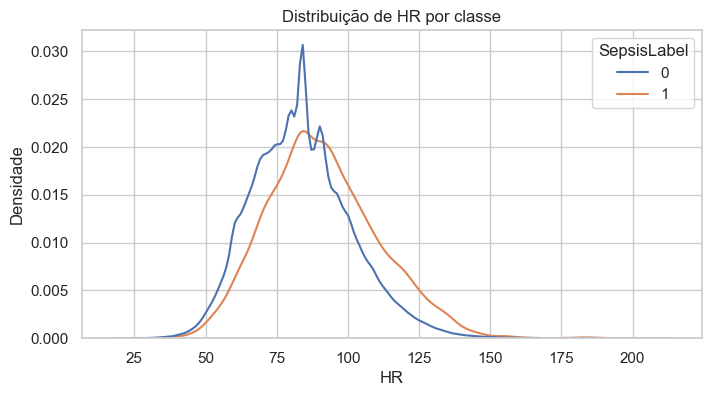

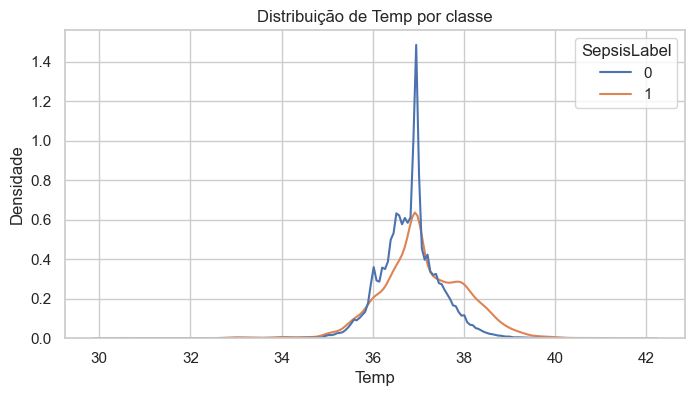

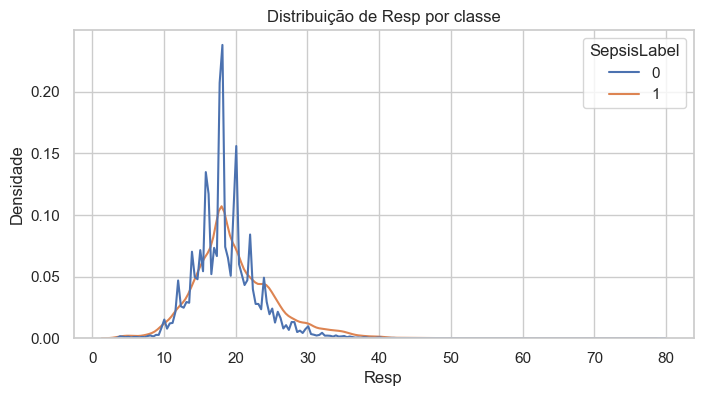

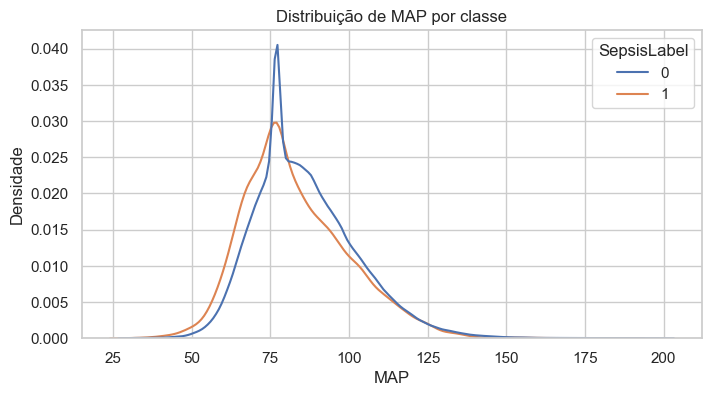

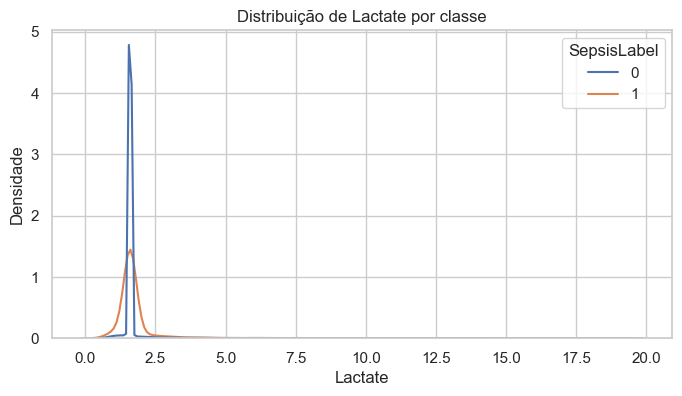

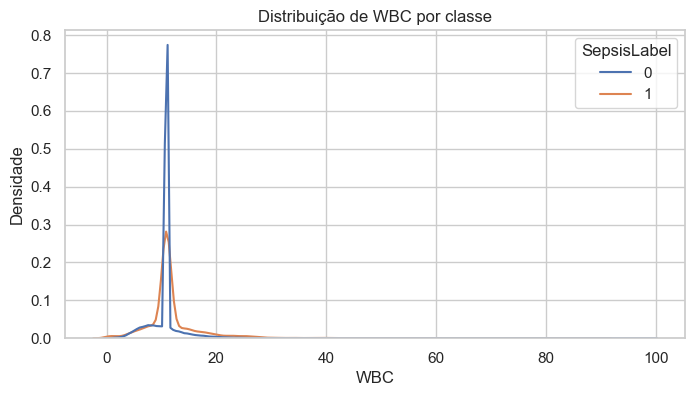

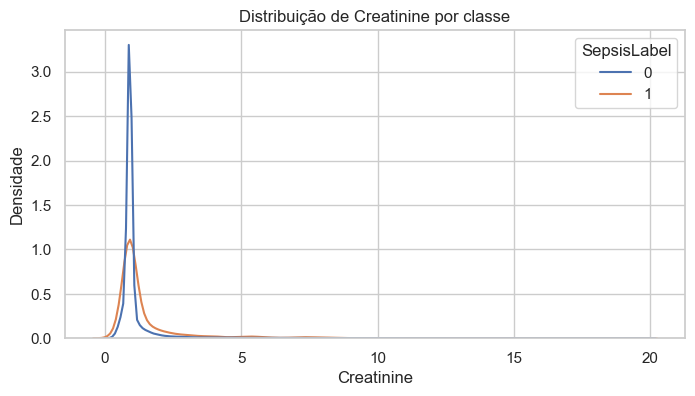

In [43]:
# Célula 123
variaveis_graficos = ["HR", "Temp", "Resp", "MAP", "Lactate", "WBC", "Creatinine"]

for var in variaveis_graficos:
    if var in df_test_feat.columns:
        plt.figure(figsize=(8, 4))
        sns.kdeplot(data=df_test_feat, x=var, hue="SepsisLabel", common_norm=False)
        plt.title(f"Distribuição de {var} por classe")
        plt.xlabel(var)
        plt.ylabel("Densidade")
        plt.show()

## Célula 124

# Interpretação das distribuições clínicas

Nestes gráficos, buscamos identificar se os registros com sepse tendem a se concentrar em faixas mais graves de determinadas variáveis ou se há grande sobreposição entre as classes.

Essa análise ajuda a entender quais variáveis parecem separar melhor os grupos e quais apresentam comportamento mais parecido entre pacientes com e sem sepse.

### Interpretação dos gráficos da célula 123 — distribuições clínicas por classe

Os gráficos desta célula comparam a distribuição de variáveis clínicas entre os pacientes **sem sepse** (`SepsisLabel = 0`) e **com sepse** (`SepsisLabel = 1`). O objetivo é verificar se essas variáveis apresentam comportamentos diferentes entre as classes e se fazem sentido do ponto de vista clínico.

De forma geral, os gráficos mostram que as distribuições das duas classes **se sobrepõem bastante**, mas a classe com sepse costuma apresentar **deslocamentos sutis para valores mais alterados**, o que é compatível com a fisiopatologia da sepse. Isso também mostra que **uma variável isolada não separa bem os grupos sozinha**, o que justifica o uso combinado de múltiplas features e de informações temporais no modelo.

#### 1. HR (frequência cardíaca)
No gráfico de **HR**, a curva dos pacientes com sepse aparece ligeiramente deslocada para a direita, indicando tendência a **frequência cardíaca mais alta**. Isso é coerente clinicamente, já que pacientes sépticos costumam apresentar **taquicardia**. Apesar disso, existe bastante sobreposição entre as classes, mostrando que apenas a frequência cardíaca não é suficiente para distinguir sepse com precisão.

#### 2. Temp (temperatura corporal)
No gráfico de **Temp**, os pacientes com sepse apresentam distribuição um pouco mais espalhada e com maior presença em temperaturas mais elevadas. Isso sugere tendência a **febre** ou maior instabilidade térmica nos casos com sepse. Ainda assim, há forte concentração das duas classes em torno de valores próximos do normal, o que reforça que a temperatura sozinha não resolve a classificação.

#### 3. Resp (frequência respiratória)
No gráfico de **Resp**, a classe com sepse também tende a aparecer em valores ligeiramente mais altos, sugerindo **taquipneia** com maior frequência. Esse comportamento faz sentido, pois aumento da frequência respiratória é um sinal comum de deterioração clínica e resposta inflamatória sistêmica. Mais uma vez, porém, as curvas se sobrepõem bastante.

#### 4. MAP (pressão arterial média)
No gráfico de **MAP**, a curva dos pacientes com sepse parece levemente deslocada para valores menores. Isso sugere tendência a **pressão arterial média mais baixa**, o que é coerente com disfunção hemodinâmica e risco de choque séptico. É um achado importante, porque redução de perfusão é clinicamente relevante em sepse.

#### 5. Lactate (lactato)
No gráfico de **Lactate**, observa-se que a classe com sepse apresenta distribuição mais espalhada e com cauda mais evidente para valores maiores. Isso sugere que pacientes com sepse tendem a ter **lactato mais elevado ou mais variável**, o que é clinicamente muito importante, já que lactato alto pode indicar hipoperfusão tecidual. Mesmo assim, muitos valores permanecem em faixas próximas entre as classes.

#### 6. WBC (leucócitos)
No gráfico de **WBC**, a classe com sepse mostra distribuição um pouco mais ampla, sugerindo maior ocorrência de **leucocitose ou desregulação inflamatória**. Isso faz sentido, pois alterações nos leucócitos são comuns em processos infecciosos e inflamatórios. No entanto, a sobreposição ainda é grande, indicando que esse marcador isolado também não separa as classes de forma limpa.

#### 7. Creatinine (creatinina)
No gráfico de **Creatinine**, a distribuição dos pacientes com sepse parece mais espalhada e com maior presença em valores mais altos. Isso sugere maior chance de **disfunção renal** ou comprometimento orgânico nos pacientes com sepse. Esse é um achado coerente com quadros mais graves, em que a sepse afeta múltiplos sistemas.

### O que entendemos no conjunto dos gráficos

Analisando todas as variáveis em conjunto, os gráficos sugerem que os pacientes com sepse tendem a apresentar, em média:

- **frequência cardíaca mais alta**;
- **temperatura mais alterada**;
- **frequência respiratória mais alta**;
- **pressão arterial média mais baixa**;
- **lactato mais alto ou mais instável**;
- **leucócitos mais alterados**;
- **creatinina mais elevada**.

Esses comportamentos são clinicamente coerentes com sepse. No entanto, os gráficos também deixam claro que a separação entre as classes **não é nítida** em nenhuma variável isolada. Isso significa que o modelo precisa combinar sinais clínicos, interações entre variáveis e evolução temporal para conseguir uma classificação melhor.

### Conclusão

Em resumo, os gráficos da célula 123 mostram que:
**as variáveis clínicas escolhidas fazem sentido para o problema, porque os pacientes com sepse tendem a apresentar valores mais alterados, mas a grande sobreposição entre as distribuições indica que a detecção de sepse depende da combinação de múltiplos sinais e não de uma única medida isolada.**

## Célula 125

# Análise dos falsos positivos

Como o projeto prioriza sensibilidade, é esperado que o modelo gere um volume elevado de falsos positivos.

Por isso, é importante investigar se esses registros parecem apenas ruído do modelo ou se carregam sinais clínicos relevantes que justifiquem o alerta, mesmo sem o rótulo final de sepse.

## Célula 126

# Preparação dos resultados finais para análise de erros

Agora montamos um dataframe consolidado com:

- probabilidade prevista;
- saída da triagem sensível;
- saída do alerta forte;
- status final de triagem;
- tipo de erro em cada nível.

In [44]:
# Célula 127
results_df = df_test_feat.copy()

results_df["prob_sepse"] = y_prob_test
results_df["pred_triagem"] = y_pred_triagem
results_df["pred_alerta"] = y_pred_alerta
results_df["status_triagem"] = saida_test["status_triagem"].values

condicoes_triagem = [
    (results_df["SepsisLabel"] == 1) & (results_df["pred_triagem"] == 1),
    (results_df["SepsisLabel"] == 0) & (results_df["pred_triagem"] == 0),
    (results_df["SepsisLabel"] == 1) & (results_df["pred_triagem"] == 0),
    (results_df["SepsisLabel"] == 0) & (results_df["pred_triagem"] == 1),
]
results_df["tipo_erro_triagem"] = np.select(condicoes_triagem, ["TP", "TN", "FN", "FP"], default="Outro")

condicoes_alerta = [
    (results_df["SepsisLabel"] == 1) & (results_df["pred_alerta"] == 1),
    (results_df["SepsisLabel"] == 0) & (results_df["pred_alerta"] == 0),
    (results_df["SepsisLabel"] == 1) & (results_df["pred_alerta"] == 0),
    (results_df["SepsisLabel"] == 0) & (results_df["pred_alerta"] == 1),
]
results_df["tipo_erro_alerta"] = np.select(condicoes_alerta, ["TP", "TN", "FN", "FP"], default="Outro")

## Célula 128

### Entendimento da saída

Essa célula não gera gráfico.

Ela prepara a base para a análise mais importante do fim do notebook: entender os FP do alerta forte e os casos classificados como monitorar.

## Célula 129

# Frequência dos sinais clínicos nos falsos positivos

Nesta etapa avaliamos quais flags clínicas aparecem com mais frequência entre os casos classificados como sepse pelo modelo, mas que não possuem esse rótulo no conjunto de dados.

Essa análise ajuda a entender se os falsos positivos são puramente erro aleatório ou se representam pacientes com alguma instabilidade clínica relevante.

## Célula 130

# Análise dos sinais clínicos nos falsos positivos do alerta forte

Agora a análise vai focar na saída operacionalmente mais relevante: o **alerta forte**.

In [45]:
# Célula 131
fp_alerta_df = results_df[results_df["tipo_erro_alerta"] == "FP"].copy()
monitorar_df = results_df[results_df["status_triagem"] == "monitorar"].copy()

flags_cols = [c for c in results_df.columns if c.startswith("flag_")]

flags_binarias = []
flags_contagem = []

for c in flags_cols:
    valores = set(pd.Series(results_df[c]).dropna().unique().tolist())
    if valores.issubset({0, 1}):
        flags_binarias.append(c)
    else:
        flags_contagem.append(c)

print("Quantidade de FP no alerta forte:", len(fp_alerta_df))
print("Quantidade de casos em monitorar:", len(monitorar_df))

if flags_binarias and len(fp_alerta_df) > 0:
    proporcao_flags_fp = (
        fp_alerta_df[flags_binarias]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    proporcao_flags_fp.columns = ["flag", "proporcao"]
    display(proporcao_flags_fp)

Quantidade de FP no alerta forte: 421611
Quantidade de casos em monitorar: 121478


,flag,proporcao
0,flag_o2_normal,0.903043
1,flag_map_normal,0.847741
2,flag_temp_normal,0.725847
3,flag_hr_normal,0.659710
4,flag_resp_normal,0.559203
5,flag_taquicardia_90,0.411787
6,flag_taquipneia_20,0.340451
7,flag_taquipneia_22,0.290633
8,flag_taquicardia,0.242845
9,flag_taquicardia_100,0.242845


## Célula 132

# Gráfico das flags clínicas mais frequentes nos falsos positivos

A tabela de proporções mostra os sinais mais comuns nos falsos positivos, mas o gráfico facilita a interpretação clínica.

Isso ajuda a entender se os falsos positivos possuem alguma coerência fisiológica relevante.

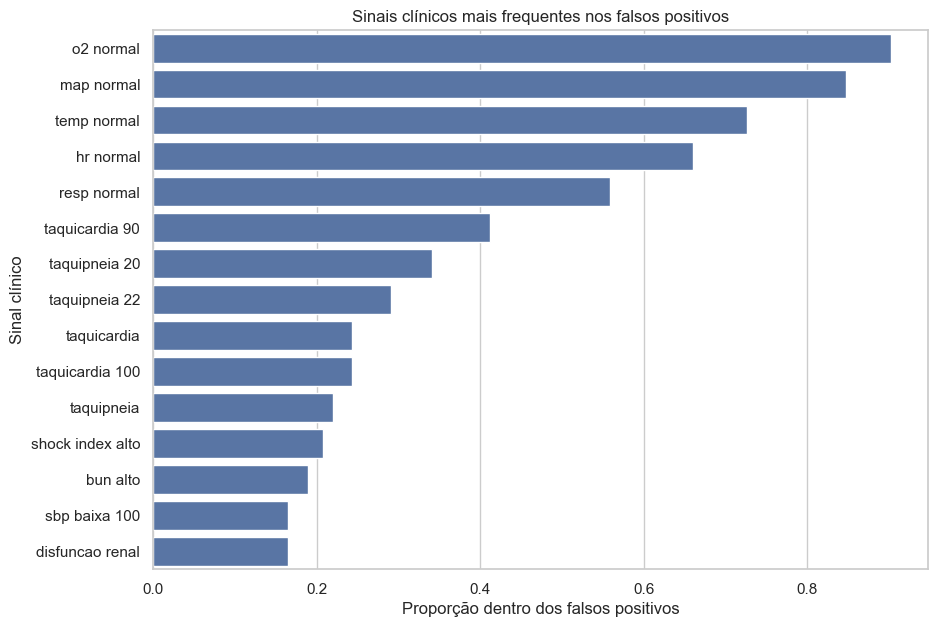

In [46]:
# Célula 133

def plotar_flags_falsos_positivos(fp_df, flags_binarias):
    base = (
        fp_df[flags_binarias]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    base.columns = ["flag", "proporcao"]
    base["flag"] = (
        base["flag"]
        .str.replace("flag_", "", regex=False)
        .str.replace("_", " ", regex=False)
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(data=base, x="proporcao", y="flag")
    plt.title("Sinais clínicos mais frequentes nos falsos positivos")
    plt.xlabel("Proporção dentro dos falsos positivos")
    plt.ylabel("Sinal clínico")
    plt.show()


if flags_binarias and len(fp_alerta_df) > 0:
    plotar_flags_falsos_positivos(fp_alerta_df, flags_binarias)

## Célula 134

### Entendimento da saída

Se algumas flags clínicas aparecem com frequência alta nos falsos positivos, isso pode indicar que esses casos não são totalmente aleatórios.

Eles podem representar pacientes com alguma instabilidade fisiológica, com quadro intermediário, com risco aumentado ou até com possível inconsistência do rótulo original.

### Interpretação do gráfico: sinais clínicos mais frequentes nos falsos positivos

Este gráfico mostra quais sinais clínicos aparecem com maior frequência entre os casos classificados pelo modelo como **sepse**, mas que nos dados estão rotulados como **não sepse** — ou seja, os **falsos positivos (FP)**.

O principal achado é que muitos falsos positivos ainda apresentam sinais considerados **normais**, com destaque para:
- **o2 normal** (oxigenação normal),
- **map normal** (pressão arterial média normal),
- **temp normal** (temperatura normal),
- **hr normal** (frequência cardíaca normal),
- **resp normal** (frequência respiratória normal).

Isso indica que uma parte importante dos pacientes que o modelo marcou como positivos **não estava claramente descompensada no momento observado**, pelo menos nos sinais vitais mais básicos. Em outras palavras, o modelo está sendo sensível e acionando alerta mesmo em muitos casos com aparência clínica ainda relativamente estável.

Ao mesmo tempo, o gráfico também mostra que vários falsos positivos apresentam alterações que fazem sentido clínico, como:
- **taquicardia 90 / taquicardia 100** (frequência cardíaca aumentada),
- **taquipneia 20 / taquipneia 22** (frequência respiratória aumentada),
- **shock index alto** (relação FC/pressão sugerindo instabilidade circulatória),
- **bun alto** (ureia aumentada),
- **sbp baixa 100** (pressão sistólica baixa),
- **disfunção renal**.

Isso sugere que os falsos positivos não são todos “erros aleatórios”. Parte deles parece representar pacientes com **algum grau de alteração fisiológica real**, mas que não receberam rótulo final de sepse. Esses casos podem corresponder, por exemplo, a:
- pacientes com outras condições clínicas graves que se parecem com sepse;
- pacientes em risco ou em fase inicial de deterioração;
- casos em que o modelo detectou instabilidade, mas sem confirmação de sepse no rótulo.

### O que entendemos deste gráfico

O gráfico sugere dois grupos principais dentro dos falsos positivos:

**1. Falsos positivos com sinais ainda normais**
- são muitos;
- ajudam a explicar por que a precisão do modelo continua baixa;
- mostram que o modelo ainda está “apitando demais”.

**2. Falsos positivos com alterações clínicas plausíveis**
- também aparecem em proporção relevante;
- indicam que parte dos FP pode ter valor clínico como alerta de risco, mesmo sem rótulo de sepse.

### Ponto importante na interpretação

As proporções do gráfico não se excluem entre si.  
O mesmo paciente pode aparecer em mais de um sinal clínico ao mesmo tempo. Portanto, o gráfico não mostra grupos separados, e sim a **frequência de cada sinal dentro do conjunto de falsos positivos**.

### Conclusão

Em resumo, este gráfico mostra que:
**os falsos positivos do modelo são mistos: muitos pacientes ainda apresentam sinais normais, o que revela excesso de sensibilidade, mas uma parte relevante apresenta alterações clínicas compatíveis com instabilidade, sugerindo que nem todo falso positivo é apenas ruído sem significado clínico.**

## Célula 135

### Entendimento da saída

Aqui você observa quais flags binárias aparecem com maior frequência nos falsos positivos do alerta forte.

Se surgirem sinais clínicos coerentes, isso sugere que os FP não são puro ruído.

## Célula 136

# Contadores temporais nos falsos positivos do alerta forte

Além das flags binárias, também é importante separar os contadores temporais, porque eles não representam proporção e sim intensidade/persistência.

,flag_count,media
0,flag_taquipneia_22_count_12h,2.810567
1,flag_taquicardia_100_count_12h,2.386285
2,flag_taquipneia_22_count_6h,1.563982
3,flag_temp_anormal_count_12h,1.405234
4,flag_taquicardia_100_count_6h,1.321922
5,flag_wbc_anormal_count_12h,1.269637
6,flag_plaqueta_baixa_count_12h,1.213818
7,flag_taquipneia_22_count_3h,0.830638
8,flag_creatinina_alta_count_12h,0.827915
9,flag_temp_anormal_count_6h,0.795077


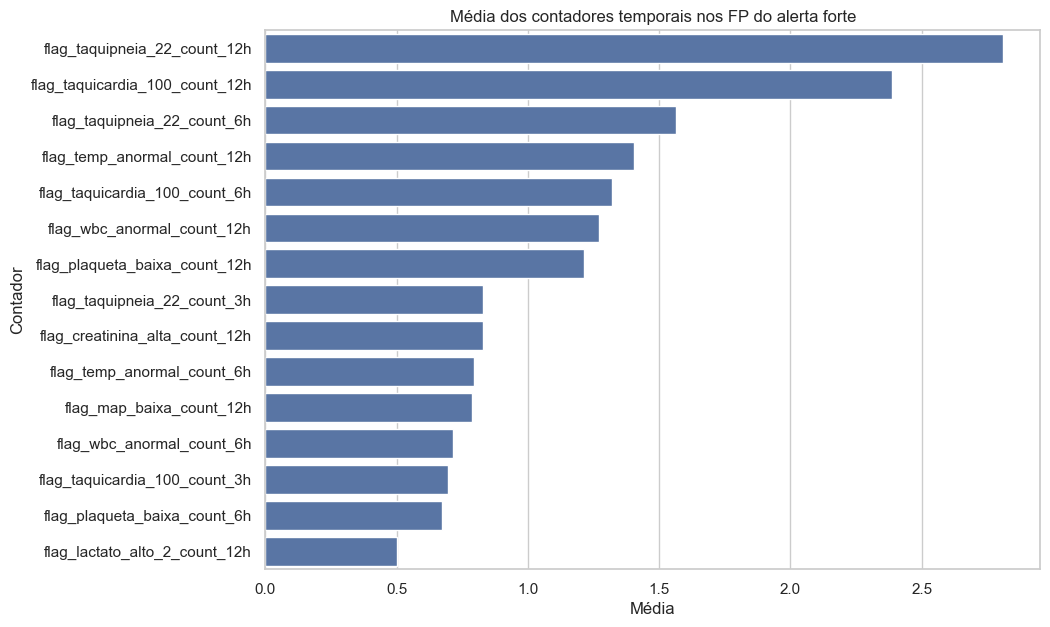

In [47]:
# Célula 137
if flags_contagem and len(fp_alerta_df) > 0:
    media_contadores_fp = (
        fp_alerta_df[flags_contagem]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    media_contadores_fp.columns = ["flag_count", "media"]
    display(media_contadores_fp)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=media_contadores_fp, x="media", y="flag_count")
    plt.title("Média dos contadores temporais nos FP do alerta forte")
    plt.xlabel("Média")
    plt.ylabel("Contador")
    plt.show()

## Célula 138

### Entendimento da saída

Se esses contadores aparecerem altos, isso indica persistência de instabilidade clínica nos casos que o modelo marcou como alerta forte.

Isso é muito mais informativo do que misturar tudo em uma média só.

### Interpretação do gráfico: média dos contadores temporais nos falsos positivos do alerta forte

Este gráfico mostra a **média de ocorrência de sinais clínicos ao longo do tempo** dentro dos casos que foram classificados como **positivos pelo alerta forte**, mas que no rótulo real eram **não sepse** — ou seja, os **falsos positivos (FP)** do alerta forte.

Diferente do gráfico anterior, que mostrava apenas a presença dos sinais, este gráfico mostra a **persistência temporal** dessas alterações. Em outras palavras, ele indica quantas vezes, em média, cada sinal apareceu nas janelas de **3h, 6h e 12h** dentro dos falsos positivos.

### Principais achados

Os maiores valores médios aparecem em:

- **`flag_taquipneia_22_count_12h`** (**quantidade de vezes em que a frequência respiratória ficou acima de 22 nas últimas 12 horas**)
- **`flag_taquicardia_100_count_12h`** (**quantidade de vezes em que a frequência cardíaca ficou acima de 100 nas últimas 12 horas**)
- **`flag_taquipneia_22_count_6h`** (**quantidade de episódios de taquipneia > 22 nas últimas 6 horas**)
- **`flag_temp_anormal_count_12h`** (**quantidade de vezes em que a temperatura ficou anormal nas últimas 12 horas**)

Isso mostra que, entre os falsos positivos do alerta forte, os sinais mais comuns não são apenas alterações isoladas, mas sim **alterações repetidas ao longo do tempo**, principalmente:
- **taquipneia persistente**;
- **taquicardia persistente**;
- **temperatura anormal recorrente**.

Também aparecem com frequência relevante:
- **`flag_wbc_anormal_count_12h`** (**alterações repetidas nos leucócitos nas últimas 12 horas**);
- **`flag_plaqueta_baixa_count_12h`** (**episódios de plaquetas baixas nas últimas 12 horas**);
- **`flag_creatinina_alta_count_12h`** (**episódios de creatinina alta nas últimas 12 horas**);
- **`flag_map_baixa_count_12h`** (**episódios de pressão arterial média baixa nas últimas 12 horas**).

Esses sinais sugerem que muitos dos falsos positivos apresentam **instabilidade clínica real e persistente**, mesmo sem o rótulo final de sepse.

### O que entendemos deste gráfico

O gráfico sugere que o **alerta forte não está errando apenas por ruído aleatório**. Muitos dos casos classificados como falso positivo apresentam um padrão de alterações repetidas ao longo do tempo, especialmente em:
- respiração;
- frequência cardíaca;
- temperatura;
- leucócitos;
- função renal;
- pressão arterial.

Isso é importante porque indica que parte desses falsos positivos pode corresponder a pacientes:
- com **deterioração clínica importante**;
- com quadro infeccioso ou inflamatório não rotulado como sepse;
- ou com **risco clínico semelhante ao da sepse**, mesmo sem confirmação no desfecho.

### Ponto mais relevante

O principal achado é que os falsos positivos do alerta forte parecem ter **persistência temporal de sinais alterados**, e não apenas valores pontuais fora da faixa normal.

Isso fortalece a interpretação de que o pipeline está captando **trajetórias de instabilidade clínica**, especialmente quando há repetição dos sinais em janelas maiores, como **6h e 12h**.

### Conclusão

Em resumo, este gráfico mostra que:
**os falsos positivos do alerta forte frequentemente apresentam alterações clínicas recorrentes ao longo do tempo, principalmente taquipneia, taquicardia e temperatura anormal, sugerindo que muitos desses casos podem representar pacientes realmente instáveis, e não apenas erros aleatórios do modelo.**

## Célula 139

# Interpretação clínica dos falsos positivos

Os falsos positivos do alerta forte devem ser interpretados com cuidado.

Se muitos deles apresentarem sinais como:

- hipotensão,
- taquipneia,
- hipoxemia,
- alteração de lactato,
- disfunção renal,
- persistência de alterações,

isso sugere que o modelo pode estar identificando pacientes fisiologicamente instáveis, ainda que o rótulo final do dataset não seja sepse.

Além disso, os casos em **monitorar** têm valor operacional importante, porque funcionam como uma zona intermediária entre ausência de alerta e prioridade alta.

## Célula 140

# Interpretação dos falsos positivos

Se os falsos positivos apresentarem com frequência sinais como hipotensão, lactato elevado, taquipneia, hipoxemia ou disfunção renal, isso sugere que parte desses registros pode representar pacientes com instabilidade importante, e não apenas erro aleatório do modelo.

Essa interpretação fortalece a visão do sistema como ferramenta de triagem, capaz de alertar para pacientes potencialmente críticos mesmo quando o rótulo final do dataset não seja sepse.

## Célula 141

# Análise opcional com SHAP

Esta etapa é opcional, mas pode enriquecer bastante a apresentação do projeto.

O objetivo é mostrar como cada variável contribui para aumentar ou reduzir a probabilidade prevista pelo modelo, o que melhora a explicabilidade do sistema.

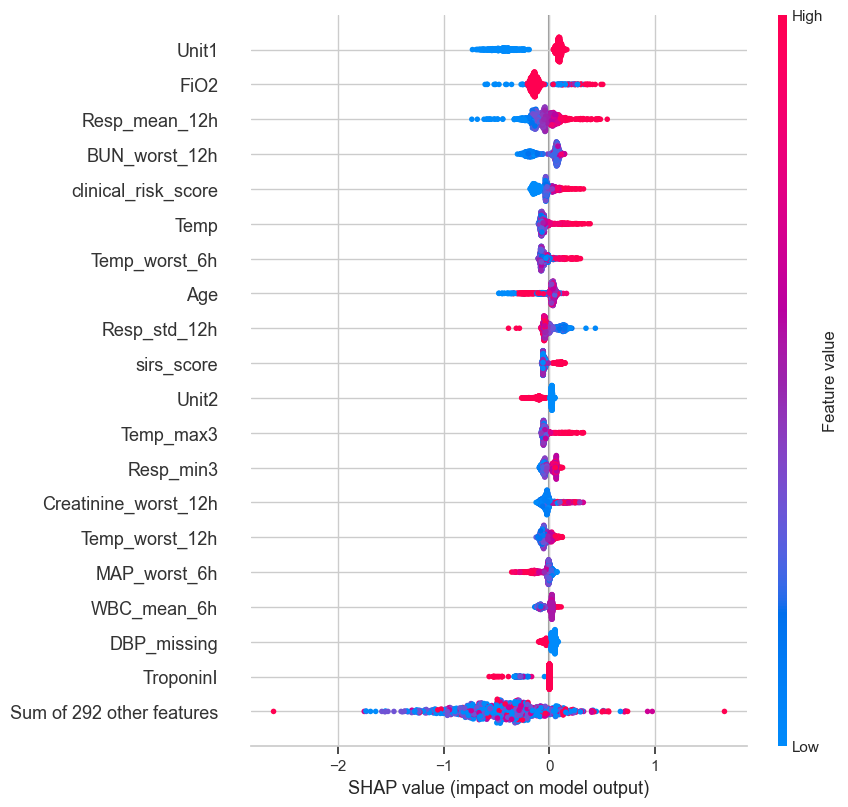

In [48]:
# Célula 142
try:
    import shap

    if "CatBoost" in melhor_nome_modelo or "XGBoost" in melhor_nome_modelo:
        amostra_shap = X_test.sample(min(1000, len(X_test)), random_state=42)
        explainer = shap.Explainer(melhor_modelo)
        shap_values = explainer(amostra_shap)
        shap.plots.beeswarm(shap_values, max_display=20)

except Exception as e:
    print("SHAP não foi executado:", e)

## Célula 143

# Interpretação do SHAP

O gráfico de SHAP mostra quais variáveis mais empurram a predição para maior risco de sepse e quais empurram a predição na direção contrária.

Essa análise ajuda a validar se o comportamento interno do modelo está alinhado com a lógica clínica esperada.

### Interpretação do gráfico SHAP summary 

Este gráfico mostra **quais variáveis mais influenciam a saída do modelo** e também **em que direção** elas empurram a predição.

#### Como ler o gráfico

- Cada linha representa uma variável.
- Cada ponto representa uma observação do conjunto analisado.
- O eixo X mostra o **valor SHAP**:
  - valores **positivos** empurram a predição para **sepse**;
  - valores **negativos** empurram a predição para **não sepse**.
- A cor mostra o valor da variável:
  - **azul** = valor mais baixo;
  - **rosa/vermelho** = valor mais alto.

Ou seja, o gráfico não mostra só importância. Ele mostra também **se valores altos ou baixos de cada variável aumentam ou reduzem o risco previsto pelo modelo**.

---

### Principais achados

#### 1. Variáveis mais influentes
As variáveis que mais impactam a decisão do modelo são:

- **Unit1**
- **FiO2**
- **Resp_mean_12h** (média da frequência respiratória nas últimas 12h)
- **BUN_worst_12h** (pior valor de ureia nas últimas 12h)
- **clinical_risk_score** (pontuação de risco clínico)
- **Temp**
- **Temp_worst_6h**
- **Age**
- **Resp_std_12h** (variação da frequência respiratória nas últimas 12h)
- **sirs_score**

Isso mostra que o modelo está usando principalmente:
- suporte/oxigenação;
- respiração;
- temperatura;
- função renal/metabólica;
- score clínico composto.

Esse conjunto é coerente com um problema de sepse.

---

#### 2. Variáveis com comportamento clinicamente coerente
O gráfico sugere que valores mais altos de algumas variáveis empurram a predição para sepse, como:

- **FiO2**: valores mais altos tendem a aumentar a saída do modelo para sepse;
- **Resp_mean_12h**: frequência respiratória média mais alta tende a aumentar risco previsto;
- **clinical_risk_score**: valores mais altos aumentam a chance prevista de sepse;
- **Temp / Temp_worst_6h / Temp_max3**: temperaturas mais altas ou piores valores recentes tendem a empurrar a predição para positivo;
- **sirs_score**: valores maiores tendem a aumentar a saída para sepse;
- **Creatinine_worst_12h**: valores mais altos tendem a aumentar o risco previsto.

Isso é coerente com a fisiopatologia da sepse, pois aponta para:
- instabilidade respiratória;
- resposta inflamatória;
- febre/alteração térmica;
- disfunção orgânica.

---

#### 3. Variáveis que merecem atenção
O gráfico também mostra variáveis importantes que não são puramente clínicas:

- **Unit1**
- **Unit2**
- **DBP_missing** (ausência do valor de pressão diastólica)

Isso é um alerta importante. Essas variáveis indicam que o modelo pode estar aprendendo também:
- diferenças entre unidades/setores/hospitais;
- padrões de coleta;
- padrões de missing.

Isso não significa necessariamente erro, mas sugere que parte do desempenho pode depender de **contexto operacional** e não só do estado clínico do paciente.

---

#### 4. Direções importantes observadas
Pelo padrão visual do gráfico:

- **Unit1** parece empurrar a predição para sepse quando presente;
- **Unit2** parece atuar no sentido oposto em parte dos casos;
- **MAP_worst_6h** sugere que certos valores de pressão arterial média recente ajudam a reduzir ou aumentar risco, dependendo da faixa;
- **TroponinI** e **DBP_missing** aparecem com impacto mais contextual do que fisiológico direto.

Isso reforça que o modelo não está usando só sinais médicos clássicos. Ele também está capturando estrutura do dado.

---

### O que entendemos desse gráfico

O gráfico SHAP mostra que o modelo:
- está usando sinais clínicos plausíveis de sepse;
- dá bastante peso para respiração, temperatura, risco clínico e função orgânica;
- mas também depende de variáveis de unidade e de missing, o que pode afetar a generalização.

Além disso, ele mostra uma vantagem do SHAP em relação ao gráfico de importância simples:
**não só quais variáveis importam, mas também se valores altos ou baixos aumentam ou reduzem a chance prevista de sepse.**

---

### Conclusão

Em resumo, este gráfico indica que:
**o modelo está apoiado em variáveis clinicamente relevantes, como FiO2, frequência respiratória, temperatura, sirs_score e creatinina, mas também apresenta dependência de variáveis contextuais como Unit1, Unit2 e DBP_missing, o que sugere a necessidade de avaliar possível viés e impacto na generalização.**

## Célula 144

# Salvamento dos artefatos do experimento

Nesta etapa final salvamos o modelo treinado e os principais artefatos necessários para reproduzir o pipeline em novos dados.

Isso inclui:

- o modelo final;
- a lista de features;
- as medianas aprendidas no treino;
- o threshold final;
- a versão do pipeline.

Esse salvamento facilita futuras inferências e garante rastreabilidade do experimento.

## Célula 145

# Salvamento dos artefatos finais

Agora salvamos não apenas o modelo, mas também os parâmetros da triagem refinada.

In [49]:
# Célula 146
artefatos_finais = {
    "modelo": melhor_modelo,
    "features": features,
    "medianas_treino": medianas_treino,
    "threshold_base": float(melhor_filtro["th_baixo"]),
    "threshold_alto": float(melhor_filtro["th_alto"]),
    "min_sinais": int(melhor_filtro["min_sinais"]),
    "versao_pipeline": VERSAO_PIPELINE,
    "usar_tempo_admin": USAR_TEMPO_ADMIN,
    "nome_modelo": melhor_nome_modelo,
}

joblib.dump(artefatos_finais, CAMINHO_MODELO)
print("Modelo salvo em:", CAMINHO_MODELO)

Modelo salvo em: c:\Users\Mathe\OneDrive\Área de Trabalho\projeto_sepse_2.0\modelos_salvos\modelo_sepse_sem_tempo_admin.pkl


## Célula 147

### Entendimento da saída

Se o salvamento ocorrer sem erro, o pipeline final fica reprodutível.

Isso é importante porque agora a sua lógica final não depende só do modelo bruto, mas também dos parâmetros da segunda camada.

## Célula 148

## Considerações finais

Este projeto teve como objetivo desenvolver um modelo de apoio à detecção de sepse a partir de dados clínicos, com foco especial na identificação precoce de pacientes em risco. Ao longo das etapas de preparação dos dados, modelagem, ajuste de threshold e análise dos resultados, ficou evidente que a detecção de sepse é um problema complexo, fortemente impactado pelo desbalanceamento entre as classes e pela sobreposição clínica entre pacientes com e sem sepse.

A análise inicial da variável alvo mostrou que a base é altamente desbalanceada, com muito mais registros de pacientes sem sepse do que com sepse. Esse cenário torna o problema mais difícil e exige cuidado na escolha das métricas, pois medidas como acurácia isoladamente não representam bem a qualidade do modelo. Por isso, o projeto priorizou métricas mais adequadas ao contexto clínico, como **recall**, **precision**, **specificity**, **F1-score**, além da análise detalhada de **falsos negativos** e **falsos positivos**.

Na comparação entre os modelos testados, o **XGBoost** apresentou o melhor equilíbrio geral no conjunto de validação, superando a Regressão Logística e apresentando desempenho semelhante ou ligeiramente superior ao CatBoost em métricas importantes. Ainda assim, os resultados mostraram que, embora o recall tenha permanecido alto, a precision continuou baixa, o que indica grande volume de falsos positivos. Isso mostrou que o modelo conseguiu ser sensível para identificar sepse, mas ainda com baixa capacidade de separar de forma limpa os casos positivos dos negativos.

A análise do comportamento do threshold reforçou esse ponto. Thresholds mais baixos aumentaram a sensibilidade e reduziram o risco de perder casos reais, mas ao custo de um número extremamente alto de falsos positivos. Já thresholds mais altos reduziram parte desse excesso de alertas, porém aumentaram os falsos negativos. Esse comportamento evidenciou um trade-off central do projeto: **quanto mais o modelo tenta evitar deixar passar pacientes com sepse, mais ele tende a superestimar risco em pacientes sem sepse**.

Com base nisso, foi estruturado um pipeline com duas saídas finais: uma **triagem sensível** e um **alerta forte**. A triagem sensível se mostrou mais adequada para rastreamento inicial, pois mantém maior recall e identifica maior proporção dos casos reais de sepse. Já o alerta forte conseguiu melhorar a especificidade e reduzir parte dos falsos positivos, mas ao custo de aumento dos falsos negativos. As matrizes de confusão absolutas e normalizadas confirmaram esse comportamento: o alerta forte filtra melhor os casos negativos, porém ainda não atinge um equilíbrio ideal, já que continua gerando muitos falsos positivos e passa a perder mais casos reais de sepse.

Outro ponto importante foi a análise das features mais relevantes. As variáveis mais importantes do modelo incluíram **scores clínicos compostos**, **temperatura**, **frequência respiratória**, **índices hemodinâmicos**, **marcadores laboratoriais** e **indicadores de disfunção orgânica**, o que mostra coerência clínica com o problema estudado. Além disso, os gráficos de distribuição por classe mostraram tendências esperadas em pacientes com sepse, como frequência cardíaca mais alta, temperatura mais alterada, frequência respiratória aumentada, lactato mais elevado, leucócitos mais alterados e creatinina mais alta. Isso reforça que o modelo está captando sinais fisiológicos plausíveis e não apenas padrões aleatórios dos dados.

Por outro lado, as análises de importância e SHAP também mostraram que o modelo utiliza variáveis contextuais, como **Unit1**, **Unit2** e indicadores de **missing**, o que merece atenção. Isso sugere que parte da decisão pode estar sendo influenciada não apenas pelo estado clínico do paciente, mas também pelo padrão de coleta ou pela unidade de origem dos dados. Esse é um ponto relevante, pois pode impactar a capacidade de generalização do modelo em outros ambientes.

A análise dos falsos positivos trouxe um resultado importante para a interpretação final do projeto. Embora muitos falsos positivos apresentem sinais ainda normais, uma parcela relevante deles mostrou alterações clínicas persistentes ao longo do tempo, como taquipneia, taquicardia, temperatura anormal, alteração de leucócitos, disfunção renal e queda de pressão arterial média. Isso sugere que nem todos os falsos positivos são apenas “erros sem sentido”; parte deles pode representar pacientes clinicamente instáveis, com deterioração real ou risco aumentado, mesmo sem o rótulo final de sepse. Dessa forma, o modelo se aproxima mais de uma ferramenta de **triagem de risco clínico** do que de um sistema definitivo de confirmação diagnóstica.

De forma geral, o projeto demonstrou que é possível construir um pipeline com coerência clínica e capacidade de captar boa parte dos casos de sepse, mas também evidenciou as limitações atuais do modelo. O principal desafio permanece sendo reduzir os falsos positivos sem aumentar excessivamente os falsos negativos. Em um contexto médico, esse equilíbrio é especialmente delicado, pois perder um caso real pode ter impacto grave, mas um sistema com excesso de alertas também perde utilidade prática.

Como próximos passos, o projeto pode ser evoluído com:
- refinamento das features clínicas e temporais;
- revisão das variáveis contextuais que podem induzir viés;
- calibração mais robusta de threshold;
- testes com abordagens de custo sensível;
- análise por paciente, e não apenas por registro;
- validação externa em outro conjunto de dados ou cenário clínico.

Em conclusão, os resultados indicam que o modelo desenvolvido tem valor como **ferramenta de apoio à triagem**, especialmente em uma estratégia em múltiplas etapas, mas ainda não apresenta equilíbrio suficiente para ser interpretado como um classificador final e autônomo de sepse. O trabalho, no entanto, cumpre bem o papel de demonstrar o desafio real do problema, a importância da interpretação clínica dos resultados e a necessidade de equilibrar sensibilidade e especificidade em aplicações de Machine Learning na saúde.

## Célula 149

# Referências

REYNA, M. A.; JOSEF, C.; JETER, R.; et al. Early Prediction of Sepsis from Clinical Data: the PhysioNet/Computing in Cardiology Challenge 2019. Computing in Cardiology, 2019.

SINGER, M.; DEUTSCHMAN, C. S.; SEYMOUR, C. W.; et al. The Third International Consensus Definitions for Sepsis and Septic Shock (Sepsis-3). JAMA, v. 315, n. 8, p. 801-810, 2016.

EVANS, L.; RHODES, A.; ALHAZZANI, W.; et al. Surviving Sepsis Campaign: International Guidelines for Management of Sepsis and Septic Shock 2021. Intensive Care Medicine, v. 47, p. 1181-1247, 2021.

SEYMOUR, C. W.; LIU, V. X.; IWASHYNA, T. J.; et al. Assessment of Clinical Criteria for Sepsis. JAMA, v. 315, n. 8, p. 762-774, 2016.